In [1]:
import matplotlib.pyplot as plt
import numpy as np
from _FigureJiazeHelper import *
from matplotlib.ticker import FormatStrFormatter
from _DetectabilityWithMeta import *

%load_ext autoreload
%autoreload 2

In [2]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=10)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 10  # 'large'
plt.rcParams['lines.markersize'] = 12
plt.rcParams['axes.linewidth'] = 0.5

# %matplotlib notebook
%config InlineBackend.figure_format = 'retina'

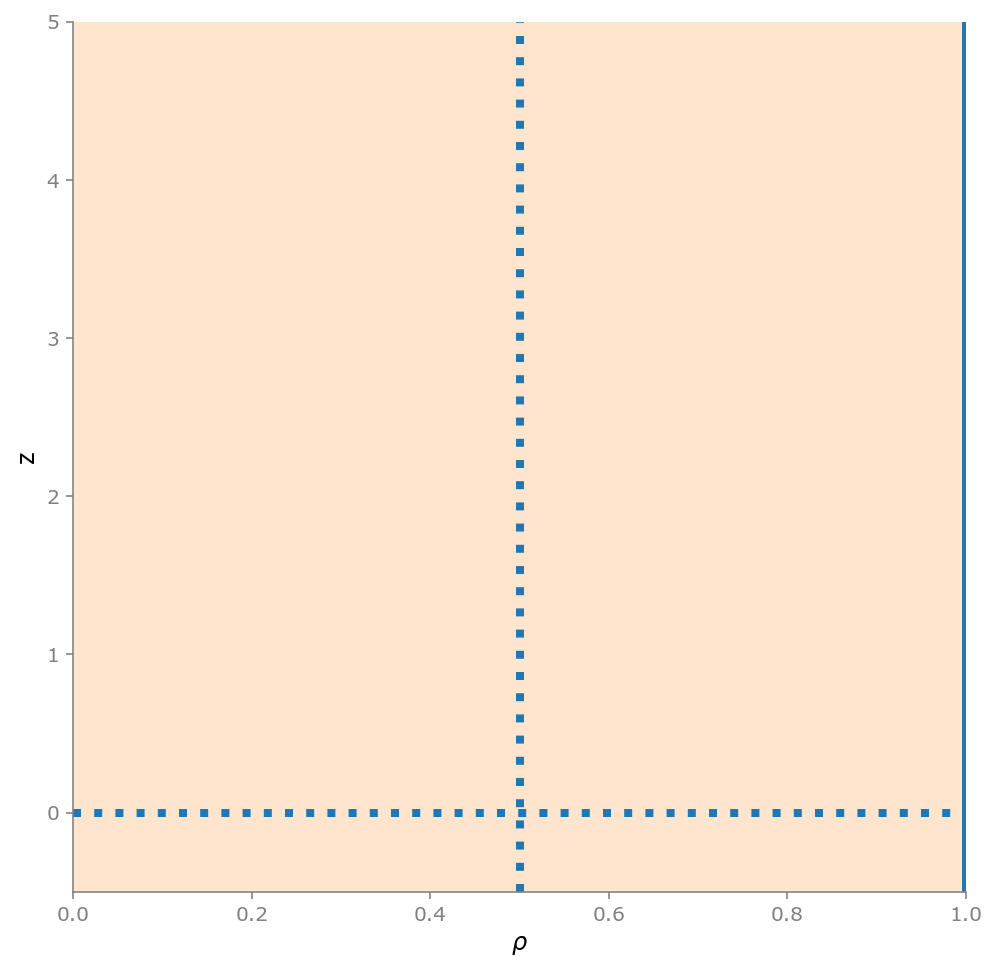

In [4]:
range_rho = np.linspace(0, 1, 200)
# border_x = np.linspace(0, 0.5, 100)
# # print(border_x)
# border_y = np.array([i/(1-2*i) for i in border_x])

fig = plt.figure(figsize=(8, 8))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
# ax.plot(border_x, border_y, 'r-', label=r'$z=\frac{\rho}{1-2\rho}$')
ax.set_xlabel(r'$\rho$')
ax.set_ylabel(r'z')
ax.set_xlim(0, 1)
ax.set_ylim(-1/2, 5)
ax.fill_between(range_rho, -1/2, 5, facecolor='C1', alpha=0.2)
plt.axvline(0.5, linestyle=':')
plt.axhline(0, linestyle=':')
plt.axvline(1, linestyle='-')
# plt.legend()

In [1]:
from _SBMMatrix import *

z 0.1333333333333333
size [81, 81, 81, 729, 729, 729]
p-link [[0.07, 0.05, 0.05, 0.05, 0.05, 0.05], [0.05, 0.07, 0.05, 0.05, 0.05, 0.05], [0.05, 0.05, 0.07, 0.05, 0.05, 0.05], [0.05, 0.05, 0.05, 0.07, 0.05, 0.05], [0.05, 0.05, 0.05, 0.05, 0.07, 0.05], [0.05, 0.05, 0.05, 0.05, 0.05, 0.07]]


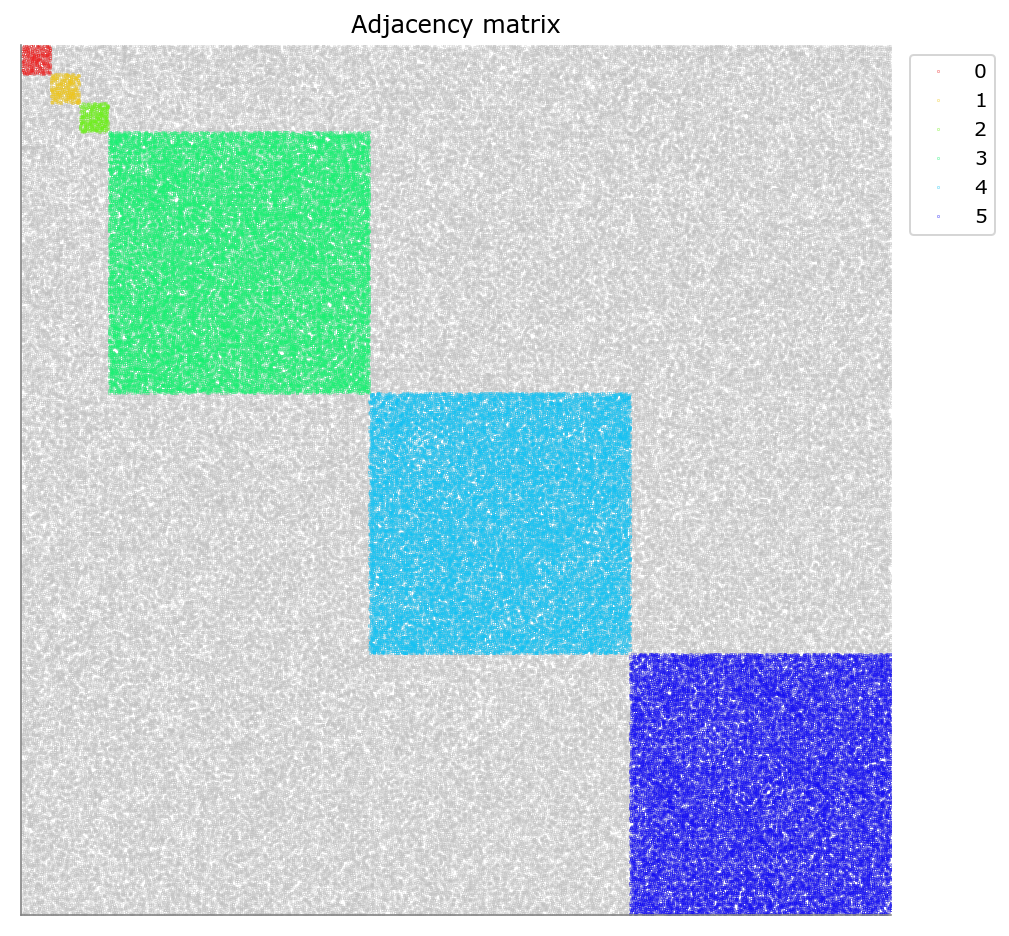

In [27]:
Q = 2
C = 3
rho = 0.1
Nqb = 3**5 * 10
sizes = []
for q in range(Q):
    for c in range(C):
        if q == 0:
            sizes.append(int(rho / C * Nqb))
        else:
            sizes.append(int((1-rho)/C * Nqb))
x = 0.02
y = 0.05
pin = x+y
pout = y
z = x / (C * y)
print("z", z)
ps = []
for i in range(len(sizes)):
    ps.append([])
    for j in range(len(sizes)):
        if j == i:
            ps[i].append(np.round(pin, 2))
        else:
            ps[i].append(np.round(pout, 2))
print("size", sizes)
print("p-link", ps)
sbm = SBMMatrix(sizes, ps)

fig = plt.figure(figsize=(8, 8))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
c = gen_colors(start=colors_red[0], end=colors_blue[0], n=len(sbm.sizes))
plot_block_matrix(sbm.A, partition_names=list(range(len(sbm.sizes))), partition_counts=sbm.sizes, colors=c, ms=0.01)

In [ ]:
x = -0.02 # -0.09
y = 0.05
pin = x+y
pout = y
z = x / (C * y)
print("z", z)
ps = []
for i in range(len(sizes)):
    ps.append([])
    for j in range(len(sizes)):
        if j == i:
            ps[i].append(np.round(pin, 4))
        else:
            ps[i].append(np.round(pout, 4))
print("size", sizes)
print("p-link", ps)
sbm = SBMMatrix(sizes, ps)

fig = plt.figure(figsize=(8, 8))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
c = gen_colors(start=colors_red[0], end=colors_blue[0], n=len(sbm.sizes))
plot_block_matrix(sbm.A, partition_names=list(range(len(sbm.sizes))), partition_counts=sbm.sizes, colors=c, ms=0.01)

## SNR for SBM with metadata
For network with size $N$, Number of metadata $X$, Number of communities $q=XZ$, Aligned probability for metadata and community is $\rho$. In-group probability is $p_{in}$, between-group probability is $p_{out}$. 

For simplicity, set $X=2$, $d_{in}=\frac{Np_{in}}{q}$, $d_{out}=\frac{Np_{out}}{q}$.
$$
\begin{aligned}
\delta &= p_{in} - p_{out}\\
d &= d_{in}+(q-1)d_{out}=\frac{N}{2Z}(p_{in}+(2Z-1)p_{out})
\end{aligned}
$$

SNR for the full graph is:
$$
SNR_{nometa}=\frac{(d_{in}-d_{out})^2}{d}=\frac{N^2}{4Z^2}\frac{\delta^2}{d}
$$

SNR for the subgraph is:
$$
SNR_{meta} = 
\left\{\begin{matrix}
    \frac{2N^2}{Z}\frac{(1-\rho)^2\delta^2}{2Zd+N\delta+\sqrt{(1-2\rho)^28NZd\delta+(2Zd-N\delta)^2}}& ,\rho \in (0, \frac{1}{2})   \\
    \frac{2N^2}{Z}\frac{\rho^2\delta^2}{2Zd+N\delta+\sqrt{(1-2\rho)^28NZd\delta+(2Zd-N\delta)^2}}& ,\rho \in (\frac{1}{2}, 1) \\
\end{matrix}\right.
$$

SNR for the graph with $Z$ bigger subgraph in subgraph is $SNR_{meta}^{big_{subsub}}$.
The size of this graph is $\frac{N\rho}{2}$, number of communities is $Z$. So
$$
\begin{aligned}
d_{in}^{big_{subsub}}&=\frac{\rho Np_{in}}{2Z}\\
d_{out}^{big_{subsub}}&=\frac{\rho Np_{out}}{2Z}
\end{aligned}
$$
Because of
$$
\begin{aligned}
    p_{in} &= \frac{d}{N}+ \delta - \frac{1}{2Z}\delta \\
    p_{out} &= \frac{d}{N} - \frac{1}{2Z}\delta \enspace .
\end{aligned}
$$
So
$$
\begin{aligned}
d^{big_{subsub}}&= d_{in}^{big_{subsub}}+(Z-1)d_{out}^{big_{subsub}}\\
&=\frac{\rho N}{2Z}(\frac{d}{N}+ \delta - \frac{1}{2Z}\delta+(Z-1)(\frac{d}{N} - \frac{1}{2Z}\delta))\\
&=\frac{\rho N}{2Z}(\frac{d}{N}Z+\frac{\delta}{2})\\
&=\frac{\rho d}{2}+\frac{\rho N}{4Z}\delta
\end{aligned}
$$
So
$$
\begin{aligned}
SNR_{meta}^{big_{subsub}}&=\frac{(d_{in}^{big_{subsub}}-d_{out}^{big_{subsub}})^2}{d^{big_{subsub}}}\\
&=\frac{(\frac{\rho N}{2Z})^2\delta^2}{\frac{\rho d}{2}+\frac{\rho N}{4Z}\delta}\\
&=\frac{\rho N^2\delta^2}{2Z^2d+NZ\delta}
\end{aligned}
$$

Z=3, d=50, min_delta=-0.005, max_delta=0.025
min SNR_m: 0.01
max SNR_m: 50.00000000000001


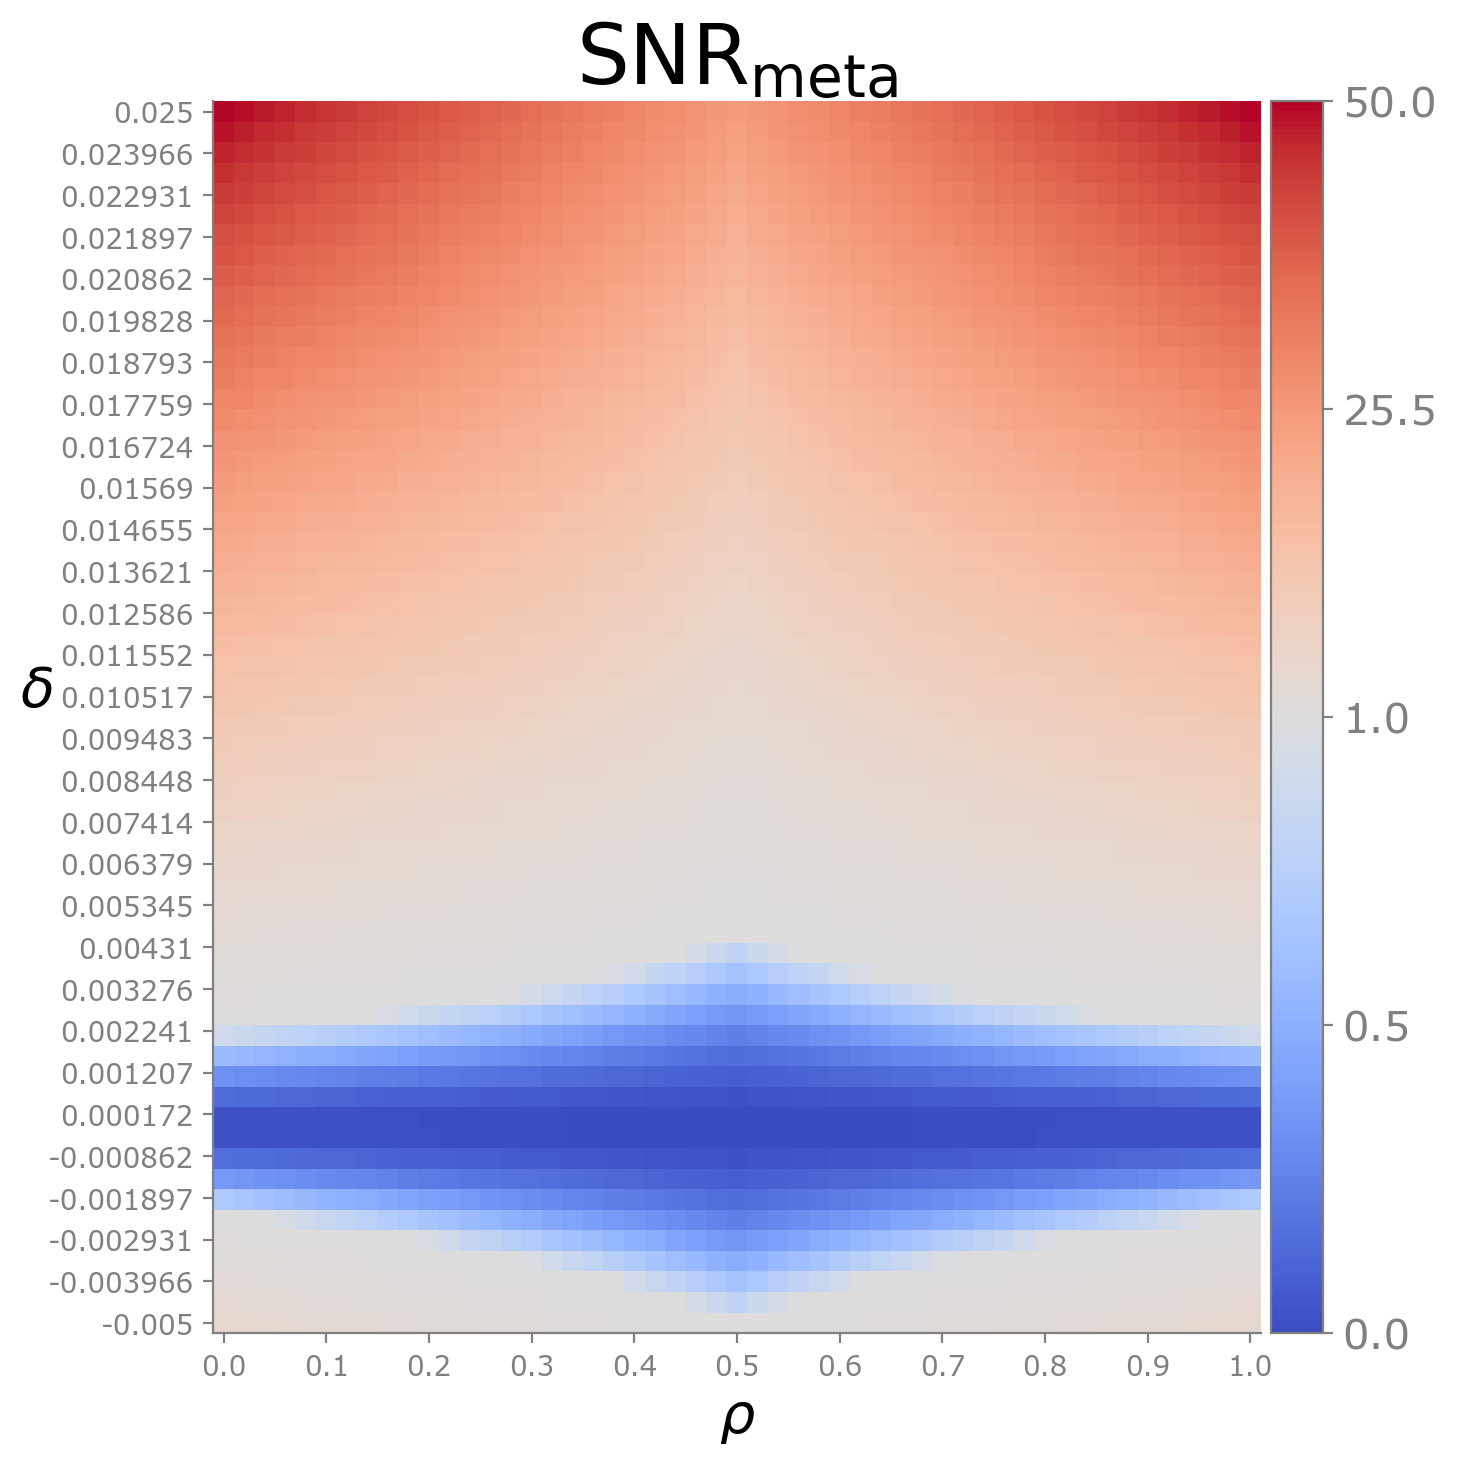

In [43]:
rho = np.setdiff1d(np.around(np.linspace(0, 1, 51), 2), np.array([]))
# delta = np.setdiff1d(np.around(np.arange(-1, 1, 0.02), 2), np.array([0]))
# print(z)
N = 12000
X = 2
Z = 3
d = 50  # 100~500
if 0 < d < N/(2*Z):
    min_delta = 2*Z*d /((1-2*Z)*N)
    max_delta = 2*Z*d / N
elif N/(2*Z) <= d < (1-1/(2*Z))*N:
    min_delta = 2*Z*d /((1-2*Z)*N)
    max_delta = (2*Z / (1-2*Z))*(d/N-1)
elif (1-1/(2*Z))*N <= d < N:
    min_delta = 2*Z*(d/N-1)
    max_delta = (2*Z / (1-2*Z))*(d/N-1)
else:
    min_delta, max_delta = None, None
delta = np.setdiff1d(np.around(np.linspace(min_delta, max_delta, int((max_delta-min_delta)/0.0005)+1), 5), np.array([0]))
SNR_m = np.zeros(np.size(delta)*np.size(rho))
SNR_nm = np.zeros(np.size(delta)*np.size(rho))
SNR_m_bigsubsub = np.zeros(np.size(delta)*np.size(rho))
i = 0
for _rho in rho:
    for _delta in delta:
        if _rho <= 1/2:
            # SNR1
            SNR_m_bigsubsub[i] = (_rho * N**2 * _delta**2) / (2 * Z**2 * d + N * Z * _delta)
            SNR_nm[i] = N**2 * _delta**2 /(4*Z**2*d)
            SNR_m[i] = 2*(N**2)*((1-_rho)**2)*(_delta**2)/(Z*(2*Z*d+N*_delta+np.sqrt((2*Z*d-N*_delta)**2+(8*N*Z*d*_delta)*((1-2*_rho)**2))))
            i+=1
        elif _rho > 1/2:
            # SNR2
            SNR_m_bigsubsub[i] = (_rho * N**2 * _delta**2) / (2 * Z**2 * d + N * Z * _delta)
            SNR_nm[i] = N**2 * _delta**2 /(4*Z**2*d)
            SNR_m[i] = 2*(N**2)*(_rho**2)*(_delta**2)/(Z*(2*Z*d+N*_delta+np.sqrt((2*Z*d-N*_delta)**2+(8*N*Z*d*_delta)*((1-2*_rho)**2))))
            i+=1
# print(np.inf in SNR)
# print(rho)
min_snr = min(np.min(SNR_m), np.min(SNR_nm), np.min(SNR_m_bigsubsub))
max_snr = max(np.max(SNR_m), np.max(SNR_nm), np.min(SNR_m_bigsubsub))
print(f"Z={Z}, d={d}, min_delta={min_delta}, max_delta={max_delta}")
print("min SNR_m:", np.min(SNR_m))
print("max SNR_m:", np.max(SNR_m))
x = np.repeat(rho, np.size(delta))
y = np.tile(delta, np.size(rho))
save_path = "./_Figure/SNR_meta_with_delta_d_" + str(d) + "_FINAL_imshow.png"
# save_path=None
fig = plt.figure(figsize=(8, 8))
widths = [8]
heights = [8]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
_ = color_imshow_2d(x, y, SNR_m, z_center=1, title=r'$\rm SNR_{meta}$', xlabel=r'$\rho$', ylabel=r'$\delta$', min_z=min_snr, max_z=max_snr, save_path=save_path, ax=ax, fig=fig)

Z=3, d=50, min_delta=-0.005, max_delta=0.025
min SNR_nm: 0.02
max SNR_nm: 50.00000000000001


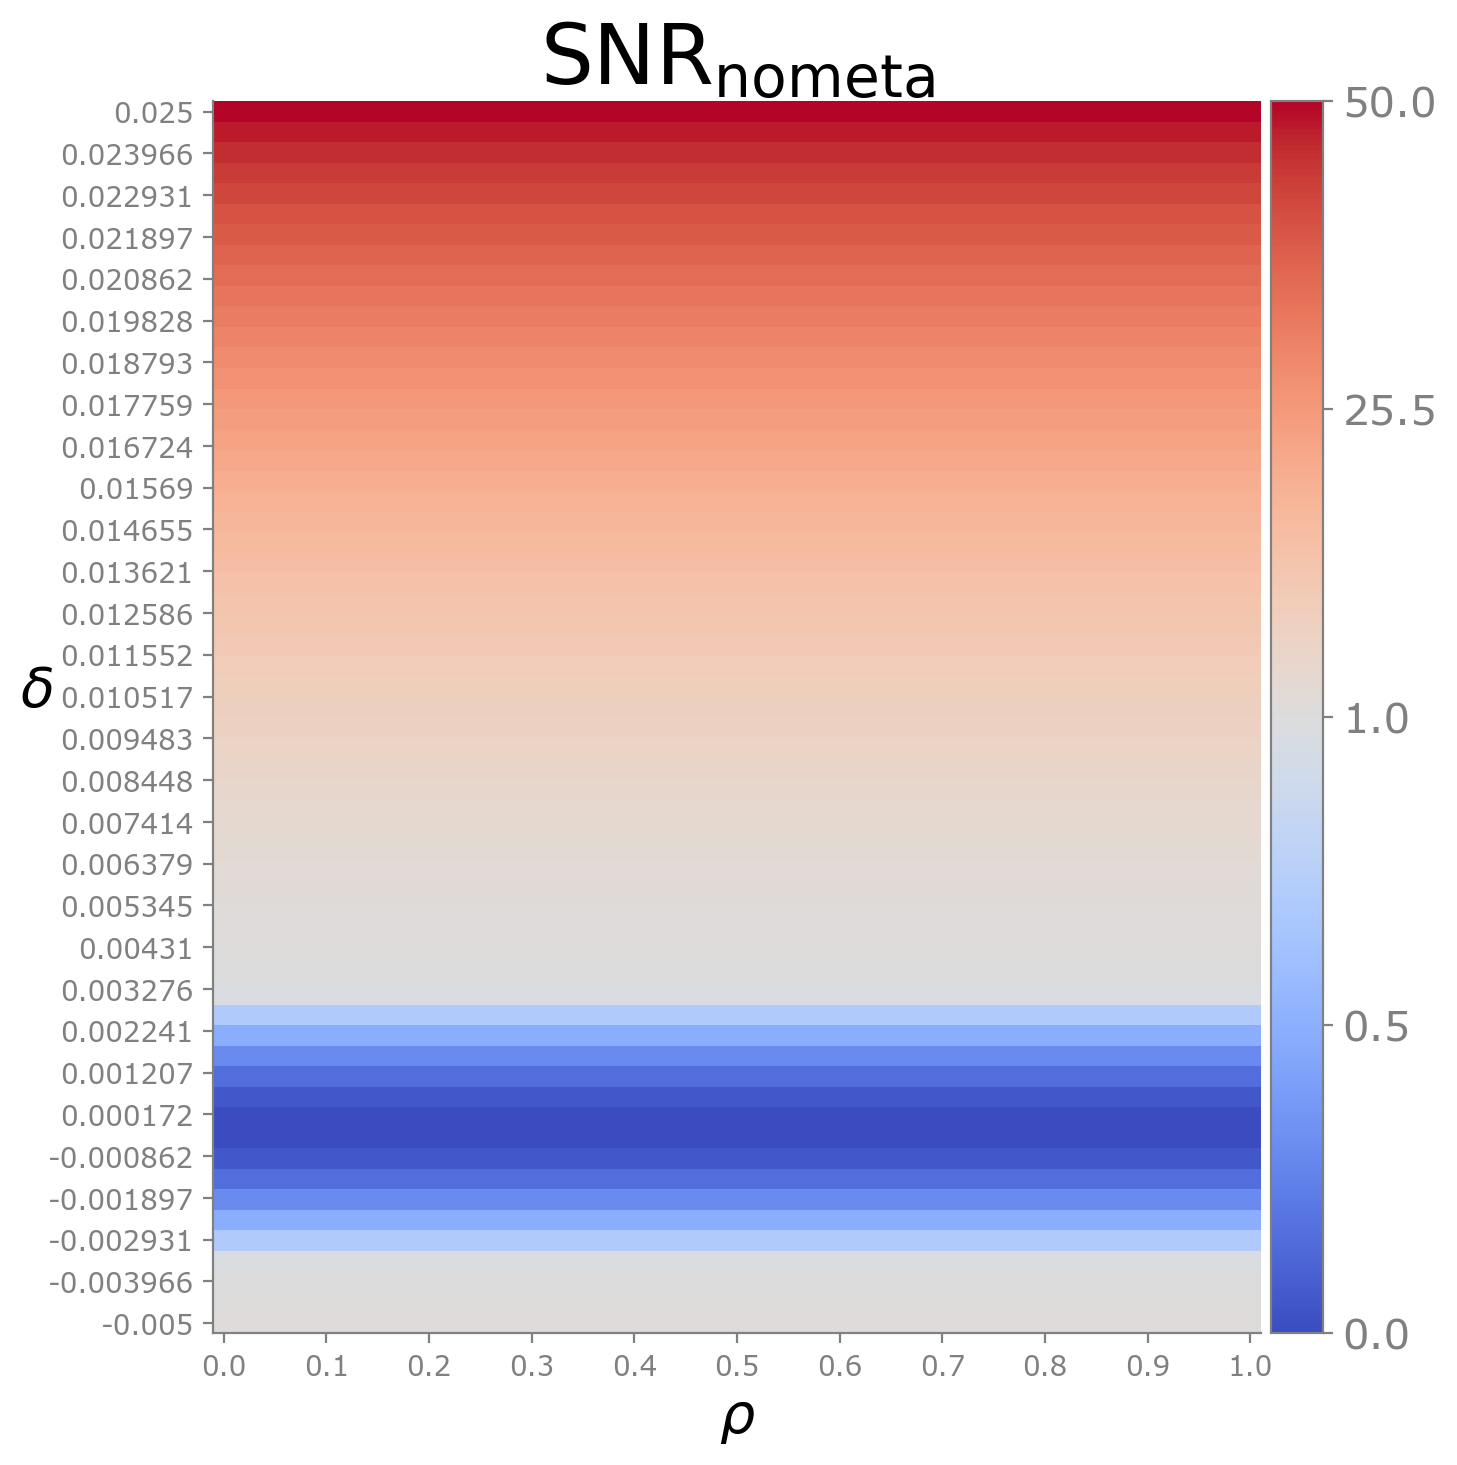

In [44]:
# SNR_nm = np.zeros(np.size(delta)*np.size(rho))
# i = 0
# for _rho in rho:
#     for _delta in delta:
#         SNR_nm[i] = N**2 * _delta**2 /(4*Z**2*d)
#         i+=1
# print(np.inf in SNR)
print(f"Z={Z}, d={d}, min_delta={min_delta}, max_delta={max_delta}")
print("min SNR_nm:", np.min(SNR_nm))
print("max SNR_nm:", np.max(SNR_nm))
x = np.repeat(rho, np.size(delta))
y = np.tile(delta, np.size(rho))
save_path = "./_Figure/SNR_nometa_with_delta_d_" + str(d) + "_FINAL_imshow.png"
# save_path=None
fig = plt.figure(figsize=(8, 8))
widths = [8]
heights = [8]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
_ = color_imshow_2d(x, y, SNR_nm, z_center=1, title=r'$\rm SNR_{nometa}$', xlabel=r'$\rho$', ylabel=r'$\delta$', min_z=min_snr, max_z=max_snr, save_path=save_path, ax=ax, fig=fig)

3060


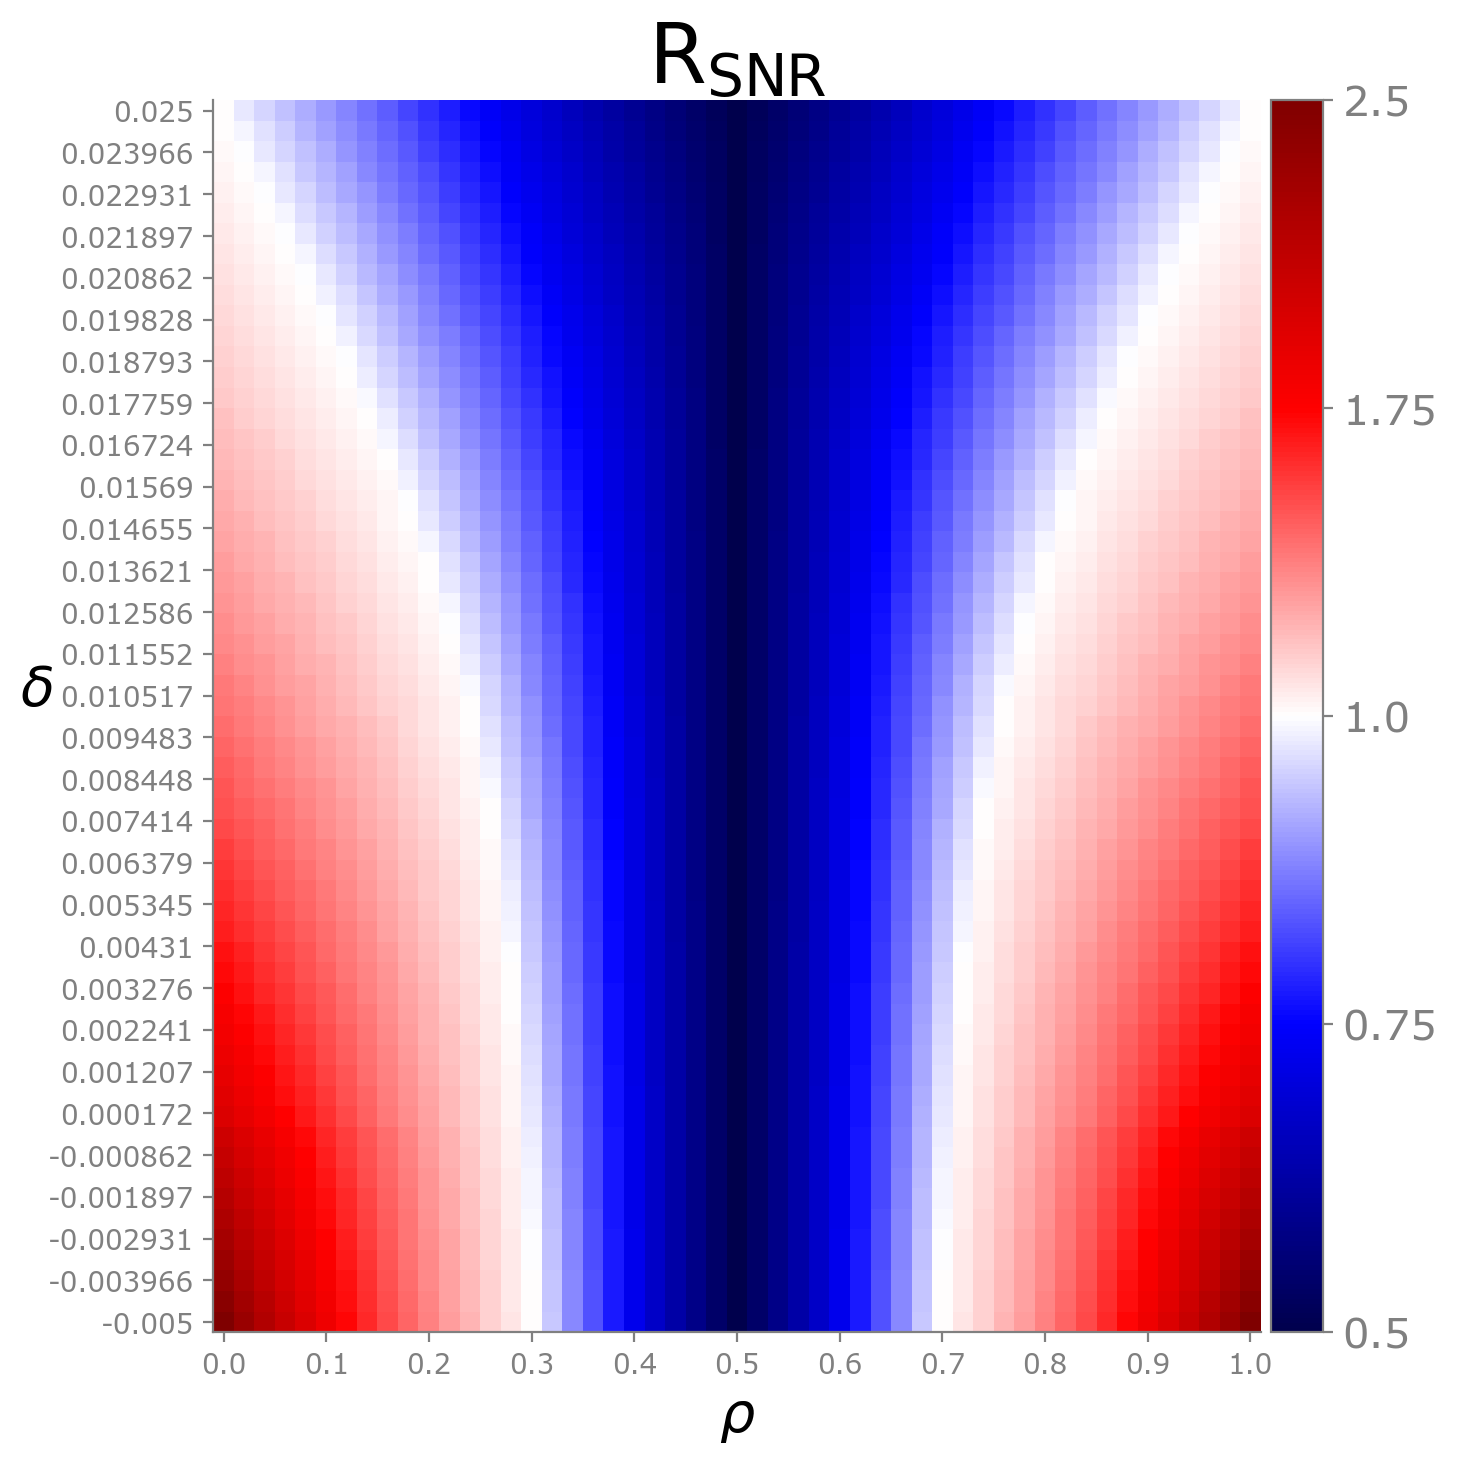

In [45]:
R_SNR=SNR_m/SNR_nm
print(np.size(R_SNR)) 
save_path = "./_Figure/R_SNR_with_delta_d_" + str(d) + "_FINAL_imshow.png"
# save_path=None
fig = plt.figure(figsize=(8, 8))
widths = [8]
heights = [8]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
_ = color_imshow_2d(x, y, R_SNR, z_center=1, title=r'$\rm R_{SNR}$', xlabel=r'$\rho$', ylabel=r'$\delta$', cmap=cm.seismic, save_path=save_path, ax=ax, fig=fig)

In [11]:
def snr_plot(N=12000, X=2, Z=3, d=50, save=True):
    rho = np.setdiff1d(np.around(np.linspace(0, 1, 51), 2), np.array([]))
    if 0 < d < N/(2*Z):
        min_delta = 2*Z*d /((1-2*Z)*N)
        max_delta = 2*Z*d / N
    elif N/(2*Z) <= d < (1-1/(2*Z))*N:
        min_delta = 2*Z*d /((1-2*Z)*N)
        max_delta = (2*Z / (1-2*Z))*(d/N-1)
    elif (1-1/(2*Z))*N <= d < N:
        min_delta = 2*Z*(d/N-1)
        max_delta = (2*Z / (1-2*Z))*(d/N-1)
    else:
        min_delta, max_delta = None, None
#     delta = np.setdiff1d(np.around(np.linspace(min_delta, max_delta, int((max_delta-min_delta)/0.0005)+1), 5), np.array([0]))
    delta = np.setdiff1d(np.around(np.linspace(min_delta, max_delta, int((max_delta-min_delta)/0.0005)+1), 5), np.array([0, min_delta]))
    SNR_m = np.zeros(np.size(delta)*np.size(rho))
    SNR_nm = np.zeros(np.size(delta)*np.size(rho))
    i = 0
    for _rho in rho:
        for _delta in delta:
            if _rho <= 1/2:
                # SNR1
                SNR_nm[i] = N**2 * _delta**2 /(4*Z**2*d)
                SNR_m[i] = 2*(N**2)*((1-_rho)**2)*(_delta**2)/(Z*(2*Z*d+N*_delta+np.sqrt((2*Z*d-N*_delta)**2+(8*N*Z*d*_delta)*((1-2*_rho)**2))))
                i+=1
            elif _rho > 1/2:
                # SNR2
                SNR_nm[i] = N**2 * _delta**2 /(4*Z**2*d)
                SNR_m[i] = 2*(N**2)*(_rho**2)*(_delta**2)/(Z*(2*Z*d+N*_delta+np.sqrt((2*Z*d-N*_delta)**2+(8*N*Z*d*_delta)*((1-2*_rho)**2))))
                i+=1
    min_snr = min(np.min(SNR_m), np.min(SNR_nm))
    max_snr = max(np.max(SNR_m), np.max(SNR_nm))
    print(f"Z={Z}, d={d}, min_delta={min_delta}, max_delta={max_delta}, min SNR_m={np.min(SNR_m)}, max SNR_m={np.max(SNR_m)}")
    x = np.repeat(rho, np.size(delta))
    y = np.tile(delta, np.size(rho))
    fig = plt.figure(figsize=(8, 8))
    widths = [2, 2, 2]
    heights = [3]
    spec5 = fig.add_gridspec(ncols=3, nrows=1, width_ratios=widths, height_ratios=heights)
    row = 0
    col = 0
    ax = fig.add_subplot(spec5[row, col])
    _ = color_imshow_2d(x, y, SNR_nm, z_center=1, title=r'$\rm SNR_{nometa}$', xlabel=r'$\rho$', ylabel=r'$\delta$', min_z=min_snr, max_z=max_snr, ax=ax, fig=fig)
    row = 0
    col = 1
    ax = fig.add_subplot(spec5[row, col])
    _ = color_imshow_2d(x, y, SNR_m, z_center=1, title=r'$\rm SNR_{meta}$', xlabel=r'$\rho$', ylabel=r'$\delta$', min_z=min_snr, max_z=max_snr, ax=ax, fig=fig)
    row = 0
    col = 2
    ax = fig.add_subplot(spec5[row, col])
    R_SNR=SNR_m/SNR_nm
    _ = color_imshow_2d(x, y, R_SNR, z_center=1, title=r'$\rm R_{SNR}$', xlabel=r'$\rho$', ylabel=r'$\delta$', cmap=cm.seismic, ax=ax, fig=fig)
    
    plt.subplots_adjust(wspace=0)
    plt.tight_layout()
    if save:
        save_path = "./_Figure/SNR_d_" + str(d) + "_imshow.pdf"
        plt.savefig(save_path, dpi=100)
    

Z=3, d=50, min_delta=-0.005, max_delta=0.025, min SNR_m=0.01, max SNR_m=50.00000000000001


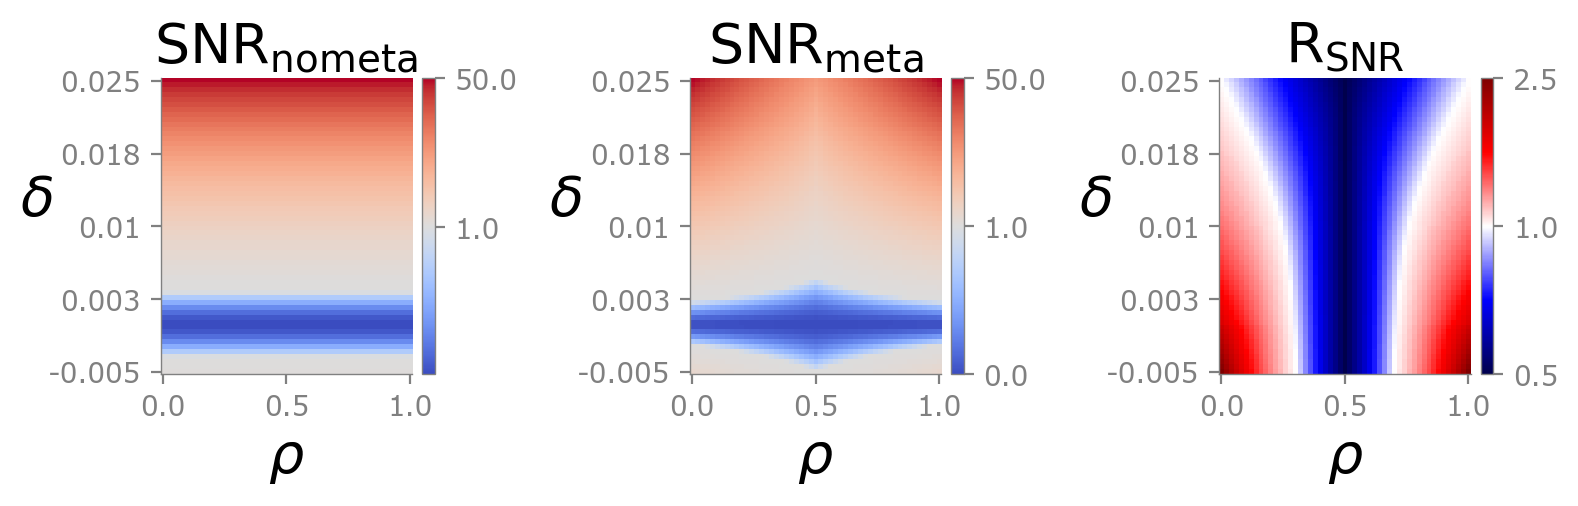

In [6]:
snr_plot()

10000


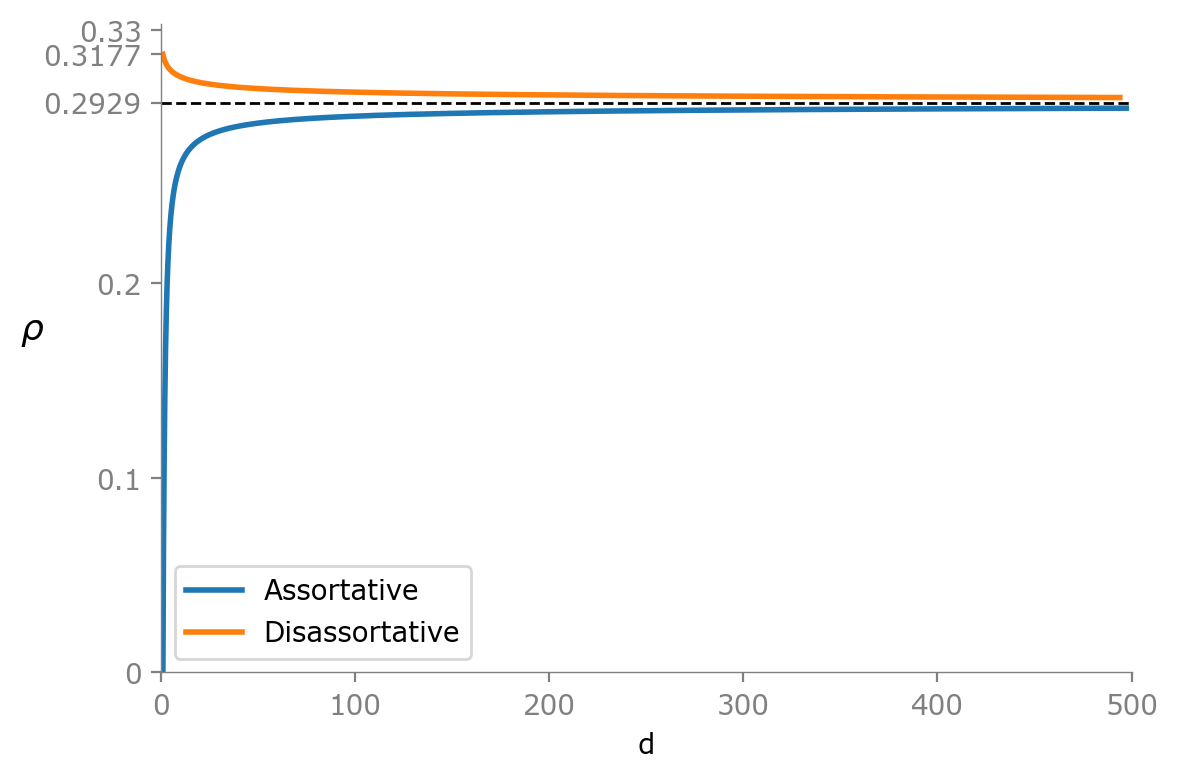

In [20]:
rhos = np.setdiff1d(np.around(np.linspace(0, 1/3, 10000), 6), np.array([0.5]))
ds = np.zeros(np.shape(rhos))
for i in range(np.size(rhos)):
    rho = rhos[i]
    ds[i] = ((3*rho - 1)/((rho - 1)*(2*rho**2-4*rho+1)))**2#  (((1-2*rho)**2+2*((1-rho)**2)-1) / (4*((1-rho)**4)-2*((1-rho)**2)))**2
print(np.size(rhos))
choose_index = np.where((ds>1)&(ds<500))[0]
rhos = rhos[choose_index]
ds = ds[choose_index]
assort_index = np.where(rhos<(2-np.sqrt(2))/2)[0]
disassort_index = np.where(rhos>=(2-np.sqrt(2))/2)[0]
fig = plt.figure(figsize=(6, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
ax.plot(ds[assort_index], rhos[assort_index], linewidth=2, label="Assortative")
ax.plot(ds[disassort_index], rhos[disassort_index], linewidth=2, label="Disassortative")
ax.set_xlabel(r'd', fontsize=10)
ax.set_ylabel(r'$\rho$', rotation='horizontal', fontsize=13)
ax.set_xlim(0, 500)
ax.set_ylim(0, 1/3)
ax.yaxis.set_major_formatter(FormatStrFormatter('%g'))
ax.set_yticks([0, 0.1, 0.2, 0.33]+[0.2929, 0.3177])
plt.axhline((2-np.sqrt(2))/2, color='k', lw=1, linestyle='--')
plt.legend()
# ax.set_xticks(np.linspace(0, np.size(_x)-1, 3), np.around(np.linspace(np.min(x), np.max(x), 3), 3), fontsize=9)

save_path = "./_Figure/cross_point.pdf"
plt.tight_layout()
plt.savefig(save_path, dpi=100)

Z=3, d=50, min_delta=-0.005, max_delta=0.025
min SNR_m_bigsubsub: 0.0
max SNR_m_bigsubsub: 50.00000000000001


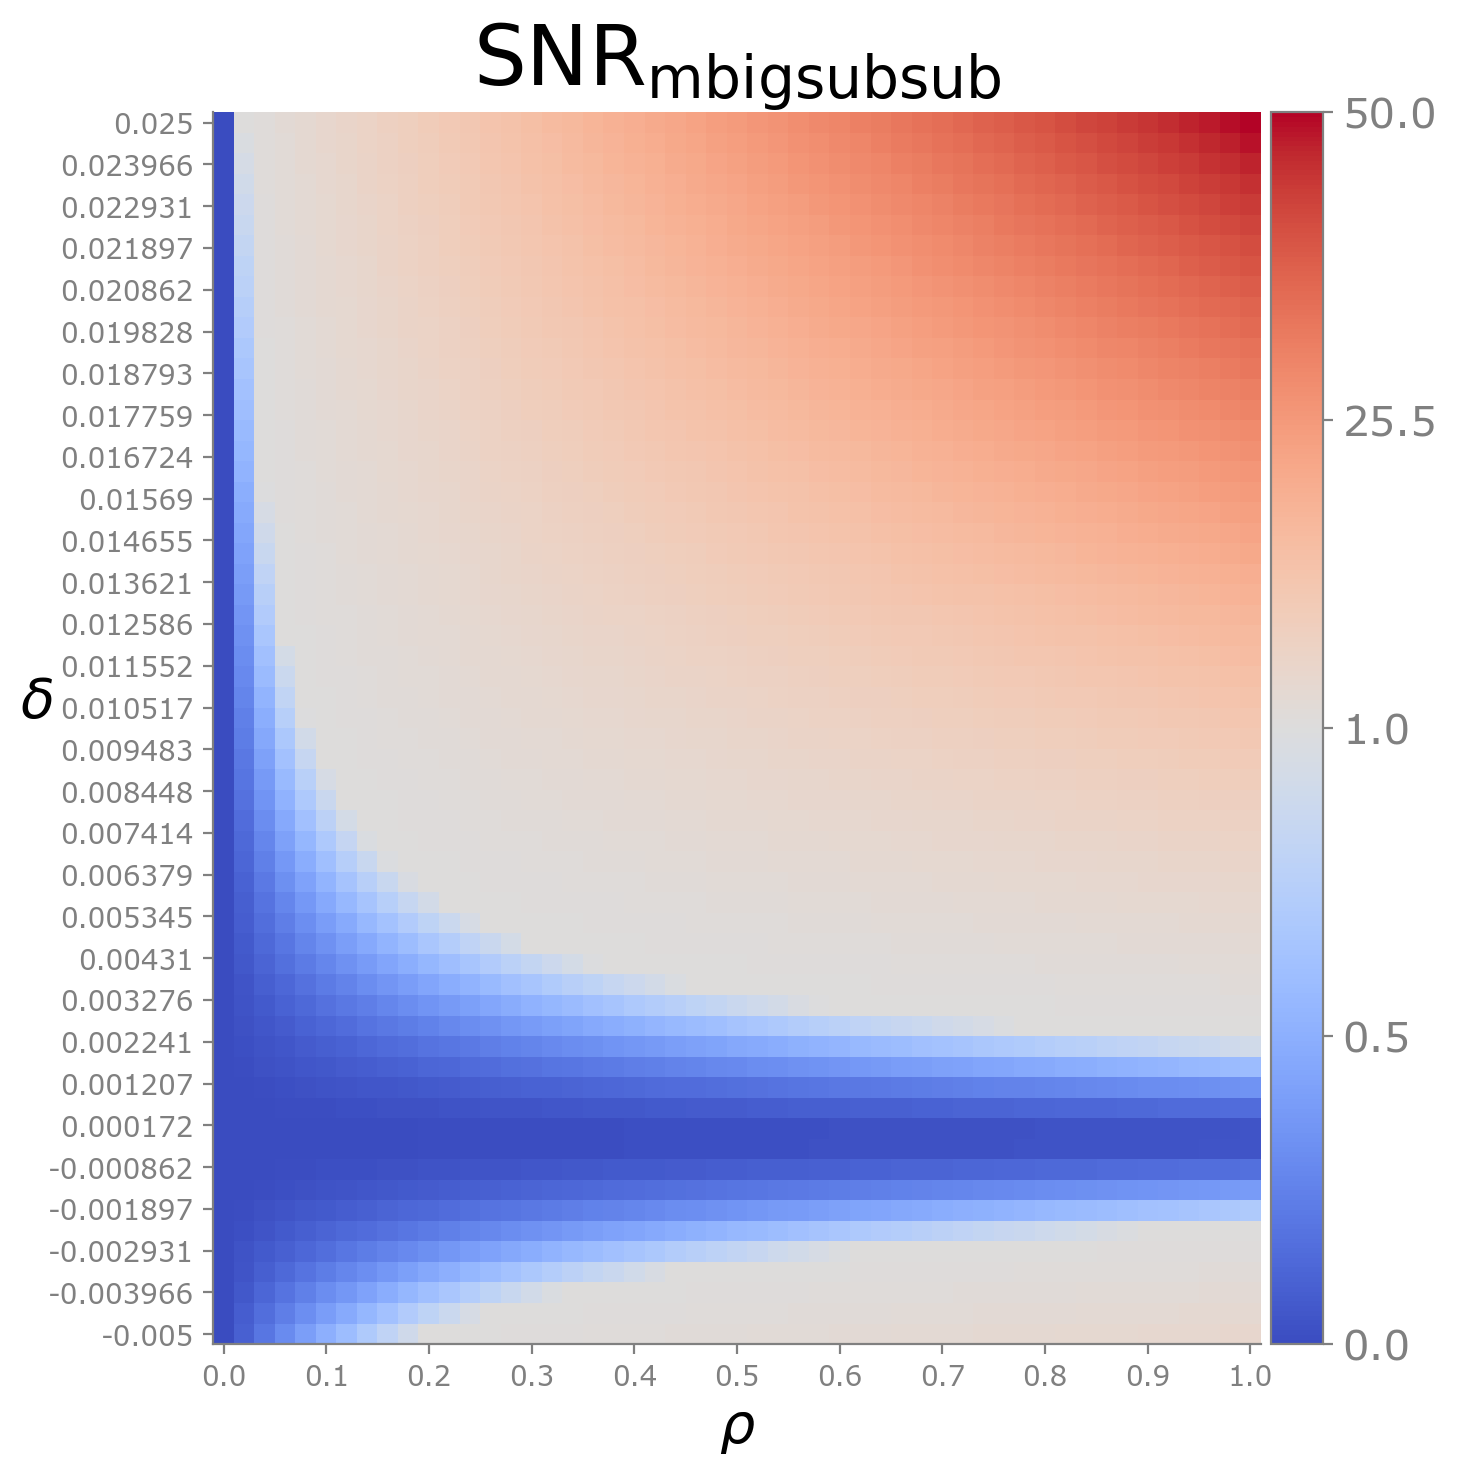

In [46]:
print(f"Z={Z}, d={d}, min_delta={min_delta}, max_delta={max_delta}")
print("min SNR_m_bigsubsub:", np.min(SNR_m_bigsubsub))
print("max SNR_m_bigsubsub:", np.max(SNR_m_bigsubsub))
x = np.repeat(rho, np.size(delta))
y = np.tile(delta, np.size(rho))
save_path = "./_Figure/SNR_metaforbigsubsub_with_delta_d_" + str(d) + "_FINAL_imshow.png"
# save_path=None
fig = plt.figure(figsize=(8, 8))
widths = [8]
heights = [8]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
_ = color_imshow_2d(x, y, SNR_m_bigsubsub, z_center=1, title=r'$\rm SNR_{mbigsubsub}$', xlabel=r'$\rho$', ylabel=r'$\delta$', min_z=min_snr, max_z=max_snr, save_path=save_path, ax=ax, fig=fig)

# Cross point

In [3]:
def SNR_data(N=12000, X=2, Z=3, d=50):
    rho = np.setdiff1d(np.around(np.linspace(0, 1, 51), 2), np.array([]))
    if 0 < d < N/(2*Z):
        min_delta = 2*Z*d /((1-2*Z)*N)
        max_delta = 2*Z*d / N
    elif N/(2*Z) <= d < (1-1/(2*Z))*N:
        min_delta = 2*Z*d /((1-2*Z)*N)
        max_delta = (2*Z / (1-2*Z))*(d/N-1)
    elif (1-1/(2*Z))*N <= d < N:
        min_delta = 2*Z*(d/N-1)
        max_delta = (2*Z / (1-2*Z))*(d/N-1)
    else:
        min_delta, max_delta = None, None
    delta = np.setdiff1d(np.around(np.linspace(min_delta, max_delta, 51), 5), np.array([0]))
    SNR_m = np.zeros(np.size(delta)*np.size(rho))
    SNR_nm = np.zeros(np.size(delta)*np.size(rho))
    i = 0
    for _rho in rho:
        for _delta in delta:
            if _rho <= 1/2:
                # SNR1
                SNR_nm[i] = N**2 * _delta**2 /(4*Z**2*d)
                SNR_m[i] = 2*(N**2)*((1-_rho)**2)*(_delta**2)/(Z*(2*Z*d+N*_delta+np.sqrt((2*Z*d-N*_delta)**2+(8*N*Z*d*_delta)*((1-2*_rho)**2))))
                i+=1
            elif _rho > 1/2:
                # SNR2
                SNR_nm[i] = N**2 * _delta**2 /(4*Z**2*d)
                SNR_m[i] = 2*(N**2)*(_rho**2)*(_delta**2)/(Z*(2*Z*d+N*_delta+np.sqrt((2*Z*d-N*_delta)**2+(8*N*Z*d*_delta)*((1-2*_rho)**2))))
                i+=1
    return rho, delta, SNR_nm, SNR_m

In [4]:
def plot_row(N, row, d=50):
    rho, delta, SNR_nm, SNR_m = SNR_data(N=N, X=2, Z=3, d=d)
    x = np.repeat(rho, np.size(delta))
    y = np.tile(delta, np.size(rho))
    min_snr, max_snr = min(np.min(SNR_m), np.min(SNR_nm)), max(np.max(SNR_m), np.max(SNR_nm))
    row = row
    col = 0
    ax = fig.add_subplot(spec5[row, col])
    plot_SNRnm = color_imshow_2d(x, y, SNR_nm, z_center=1, title=r'$\rm SNR_{nometa}$', xlabel=r'$\rho$', ylabel=r'$\delta$', min_z=min_snr, max_z=max_snr, ax=ax, fig=fig)
    row = row
    col = 1
    ax = fig.add_subplot(spec5[row, col])
    plot_SNRm = color_imshow_2d(x, y, SNR_m, z_center=1, title=r'$\rm SNR_{meta}$', xlabel=r'$\rho$', ylabel=r'$\delta$', min_z=min_snr, max_z=max_snr, ax=ax, fig=fig)
    row = row
    col = 2
    ax = fig.add_subplot(spec5[row, col])
    cmap = mpl.colormaps['plasma'].resampled(2)
    _ = color_imshow_2d(x, y, SNR_m-SNR_nm, z_center=0, title=r'$\rm SNR_{meta}-SNR_{nometa}$', xlabel=r'$\rho$', ylabel=r'$\delta$', cmap=cmap, ax=ax, fig=fig)
    contour_data(plot_SNRnm, ax, levels=[1], fmt={1: r'$SNR_{nm}$=1'}, color='white')
    contour_data(plot_SNRm, ax, levels=[1], fmt={1: r'$SNR_m$=1'}, color='white')

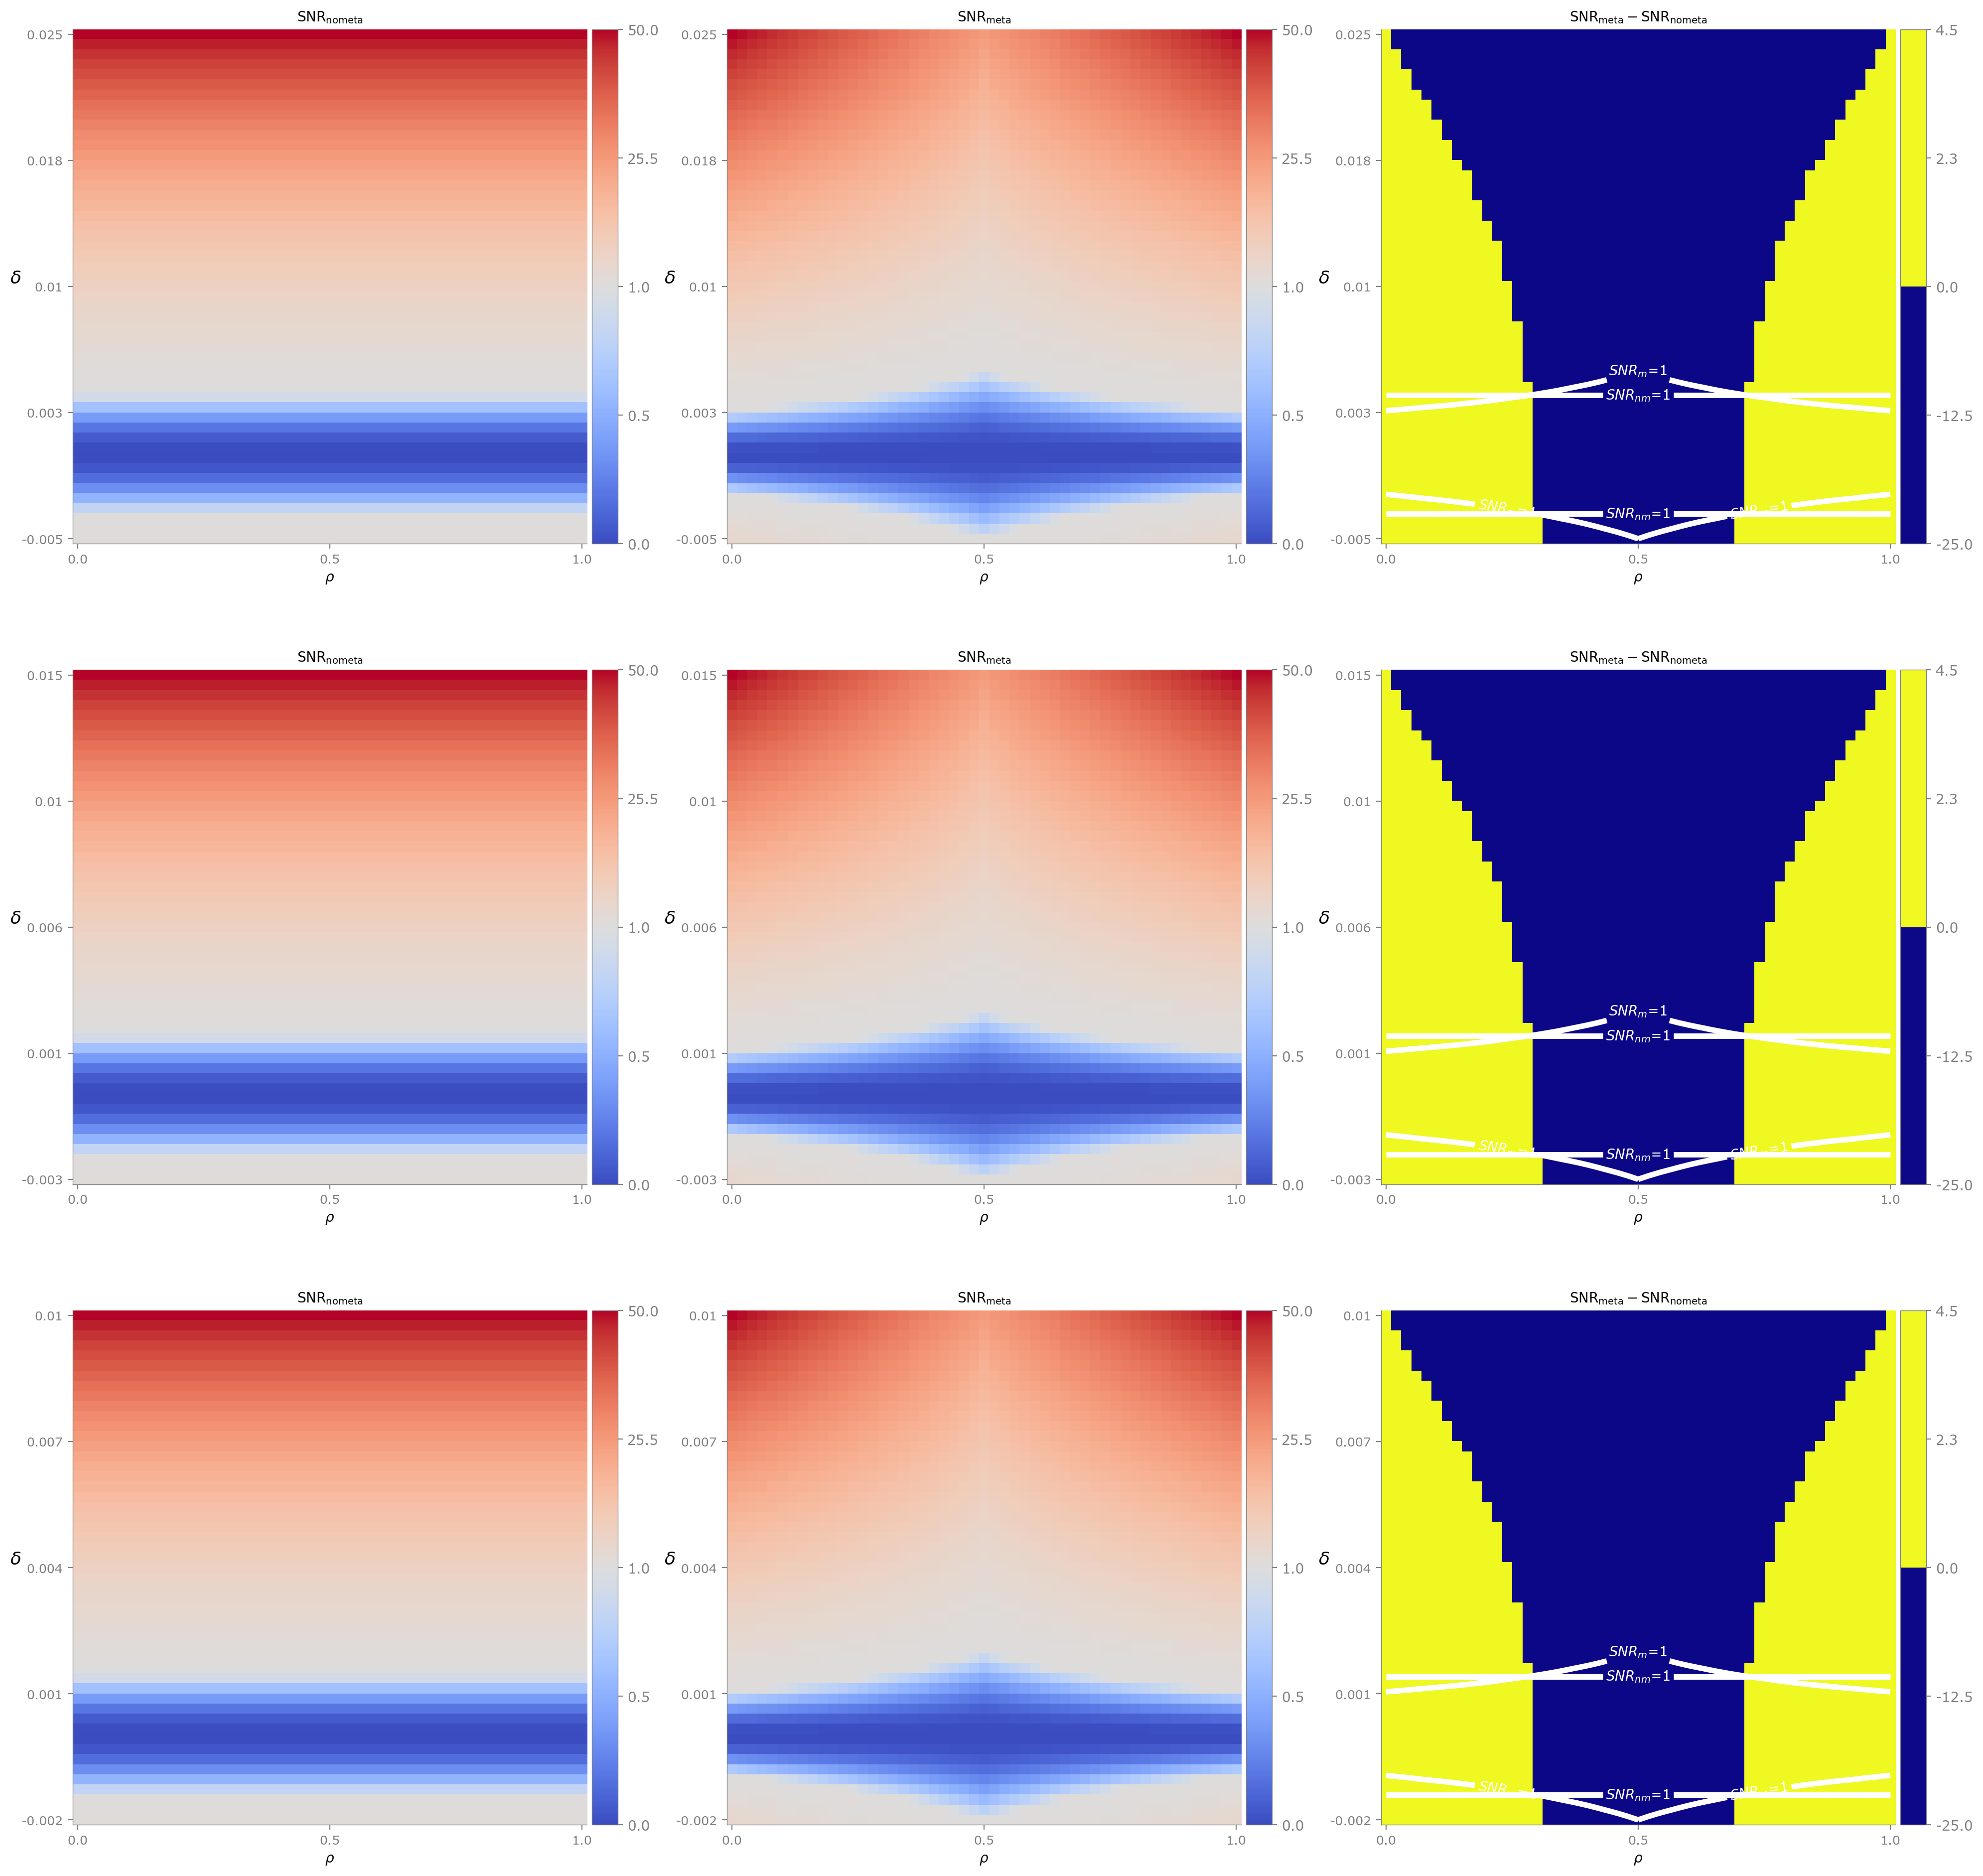

In [9]:
save_path = None
fig = plt.figure(figsize=(24, 32))
widths = [8, 8, 8]
heights = [8, 8, 8, 8]
spec5 = fig.add_gridspec(ncols=3, nrows=4, width_ratios=widths, height_ratios=heights)

plot_row(N=12000, row=0)
plot_row(N=20000, row=1)
plot_row(N=30000, row=2)

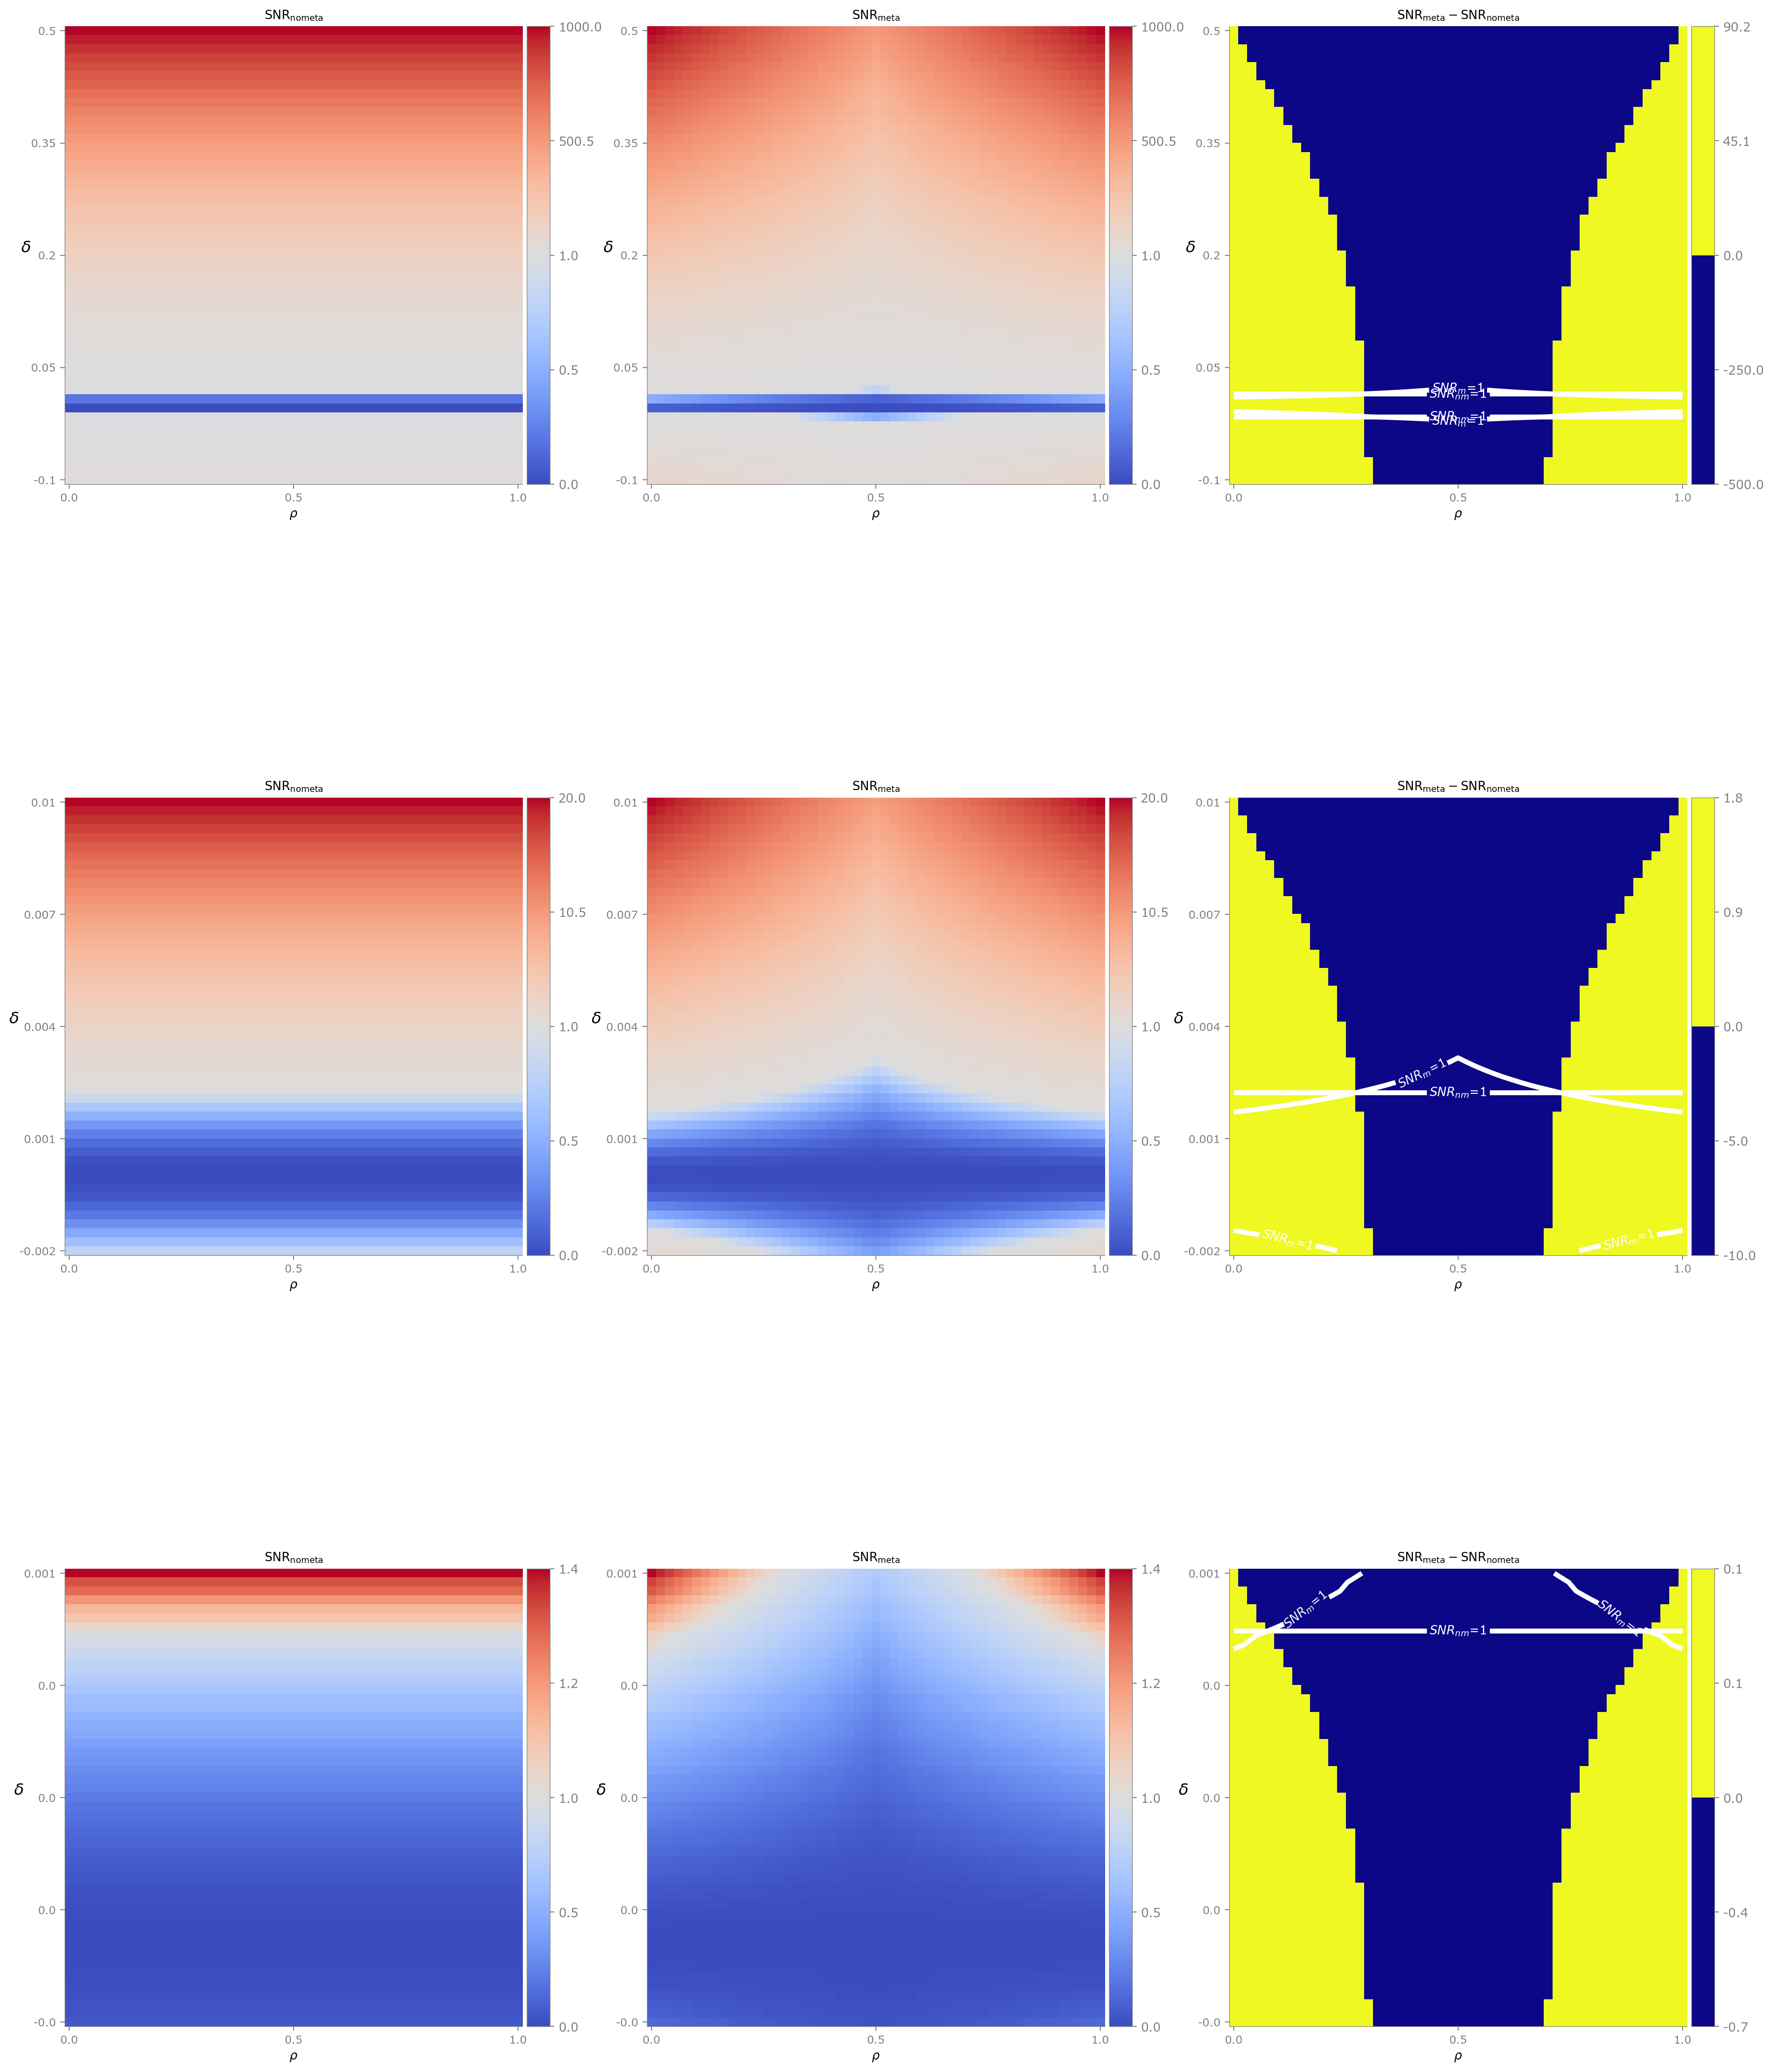

In [10]:
fig = plt.figure(figsize=(24, 32))
widths = [8, 8, 8]
heights = [8, 8, 8]
spec5 = fig.add_gridspec(ncols=3, nrows=3, width_ratios=widths, height_ratios=heights)

plot_row(N=12000, row=0, d=1000)
plot_row(N=12000, row=1, d=20)
plot_row(N=12000, row=2, d=1.4)

For Z=1, SNR_sub is 
$$
SNR_{meta} = 
    \frac{(2d+N\delta-\sqrt{(1-2\rho)^28Nd\delta+(2d-N\delta)^2})^2}{8*(2d+N\delta+\sqrt{(1-2\rho)^28Nd\delta+(2d-N\delta)^2})}
$$

For rho<1/2, the cross point
https://www.wolframalpha.com/input?i2d=true&i=plot%5C%28123%29%5C%2840%29Divide%5B%5C%2840%29y-1%5C%2841%29%5C%2840%292Power%5By%2C2%5D-4y%2B1%5C%2841%29%2C%5C%2840%293y-1%5C%2841%29%5D%5C%2841%29%5C%28125%29%5C%2844%29+0%3Cy%3C0.5

Z=1, d=50, min_delta=-0.025, max_delta=0.025
min SNR_m: 5.818347503999866e-05
max SNR_m: 25.0


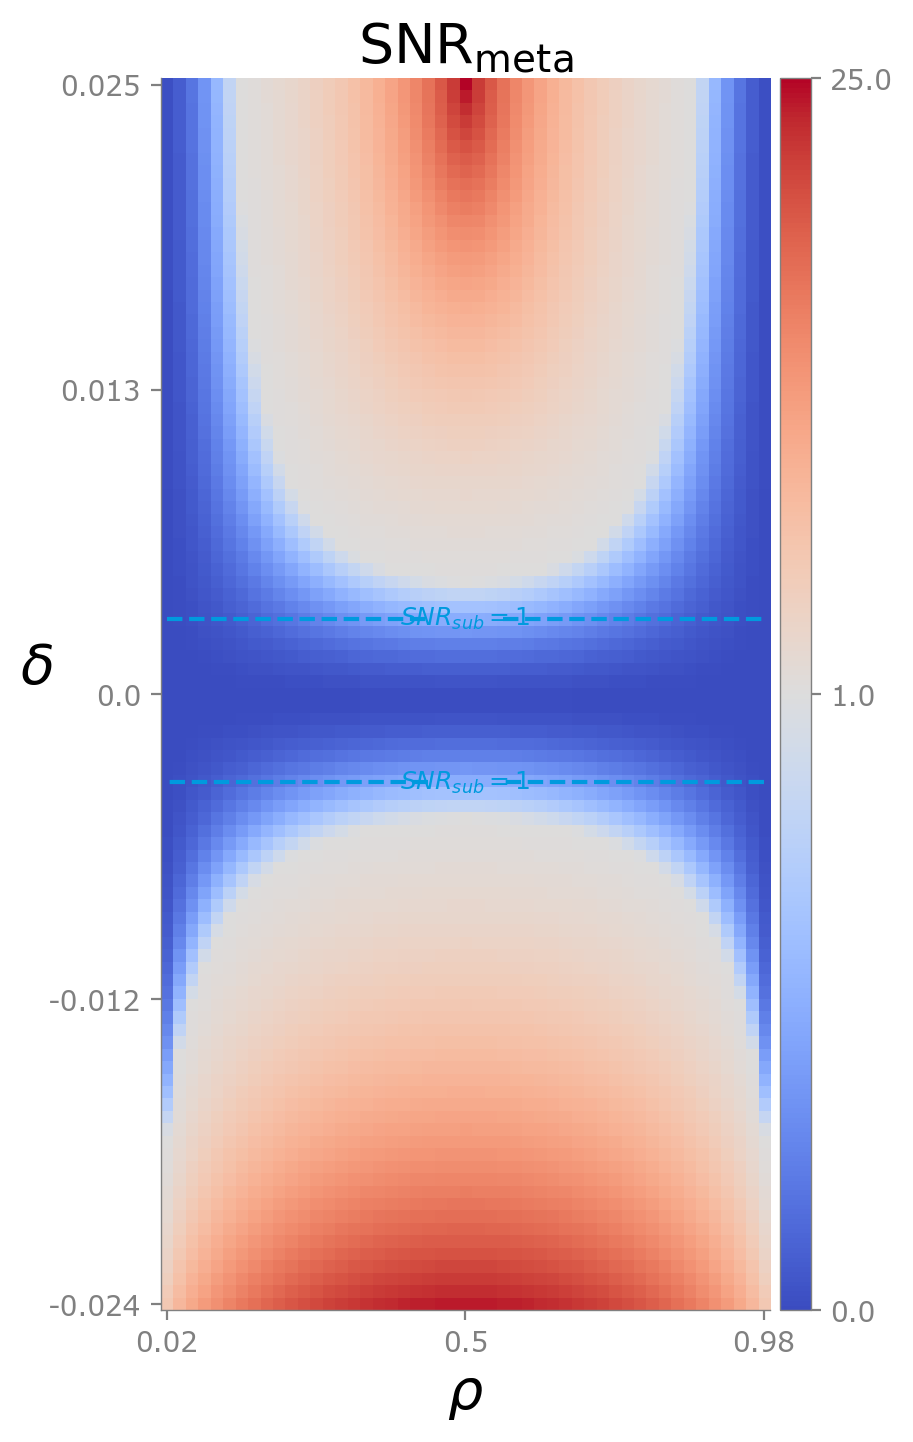

In [4]:
rho = np.setdiff1d(np.around(np.linspace(0, 1, 51), 2), np.array([0, 1]))
# delta = np.setdiff1d(np.around(np.arange(-1, 1, 0.02), 2), np.array([0]))
# print(z)
N = 4000
X = 2
Z = 1
d = 50  # 100~500
if 0 < d < N/(2*Z):
    min_delta = 2*Z*d /((1-2*Z)*N)
    max_delta = 2*Z*d / N
elif N/(2*Z) <= d < (1-1/(2*Z))*N:
    min_delta = 2*Z*d /((1-2*Z)*N)
    max_delta = (2*Z / (1-2*Z))*(d/N-1)
elif (1-1/(2*Z))*N <= d < N:
    min_delta = 2*Z*(d/N-1)
    max_delta = (2*Z / (1-2*Z))*(d/N-1)
else:
    min_delta, max_delta = None, None
delta = np.setdiff1d(np.around(np.linspace(min_delta, max_delta, int((max_delta-min_delta)/0.0005)+1), 5), np.array([0, min_delta]))
SNR_m = np.zeros(np.size(delta)*np.size(rho))
SNR_nm = np.zeros(np.size(delta)*np.size(rho))
i = 0
for _rho in rho:
    for _delta in delta:
        if _rho <= 1/2:
            # SNR1
            SNR_nm[i] = N**2 * _delta**2 /(4*Z**2*d)
            SNR_m[i] = (2*Z*d+N*_delta-np.sqrt((2*Z*d-N*_delta)**2+(8*N*Z*d*_delta)*((1-2*_rho)**2)))**2/(8*(2*Z*d+N*_delta+np.sqrt((2*Z*d-N*_delta)**2+(8*N*Z*d*_delta)*((1-2*_rho)**2))))
            i+=1
        elif _rho > 1/2:
            # SNR2
            SNR_nm[i] = N**2 * _delta**2 /(4*Z**2*d)
            SNR_m[i] = (2*Z*d+N*_delta-np.sqrt((2*Z*d-N*_delta)**2+(8*N*Z*d*_delta)*((1-2*_rho)**2)))**2/(8*(2*Z*d+N*_delta+np.sqrt((2*Z*d-N*_delta)**2+(8*N*Z*d*_delta)*((1-2*_rho)**2))))
            i+=1
# print(np.inf in SNR)
# print(rho)
min_snr = min(np.min(SNR_m), np.min(SNR_nm))
max_snr = max(np.max(SNR_m), np.max(SNR_nm))
print(f"Z={Z}, d={d}, min_delta={min_delta}, max_delta={max_delta}")
print("min SNR_m:", np.min(SNR_m))
print("max SNR_m:", np.max(SNR_m))
x = np.repeat(rho, np.size(delta))
y = np.tile(delta, np.size(rho))
save_path = None
# save_path=None
fig = plt.figure(figsize=(8, 8))
widths = [8]
heights = [8]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
_ = color_imshow_2d(x, y, SNR_m, z_center=1, title=r'$\rm SNR_{meta}$', xlabel=r'$\rho$', ylabel=r'$\delta$', min_z=None, max_z=None, save_path=save_path, ax=ax, fig=fig)
plot_snrnm = color_imshow_2d(x, y, SNR_nm, z_center=1, return_gridz=True)
contour_data(plot_snrnm, ax, levels=[1], fmt={1: r'$SNR_{sub}=1$'}, color='#009ade', linestyle='dashed')

Z=1, d=50, min_delta=-0.025, max_delta=0.025
min SNR_nm: 0.02
max SNR_nm: 50.00000000000001
min SNR=0.00046546780031998927
max SNR=200.0


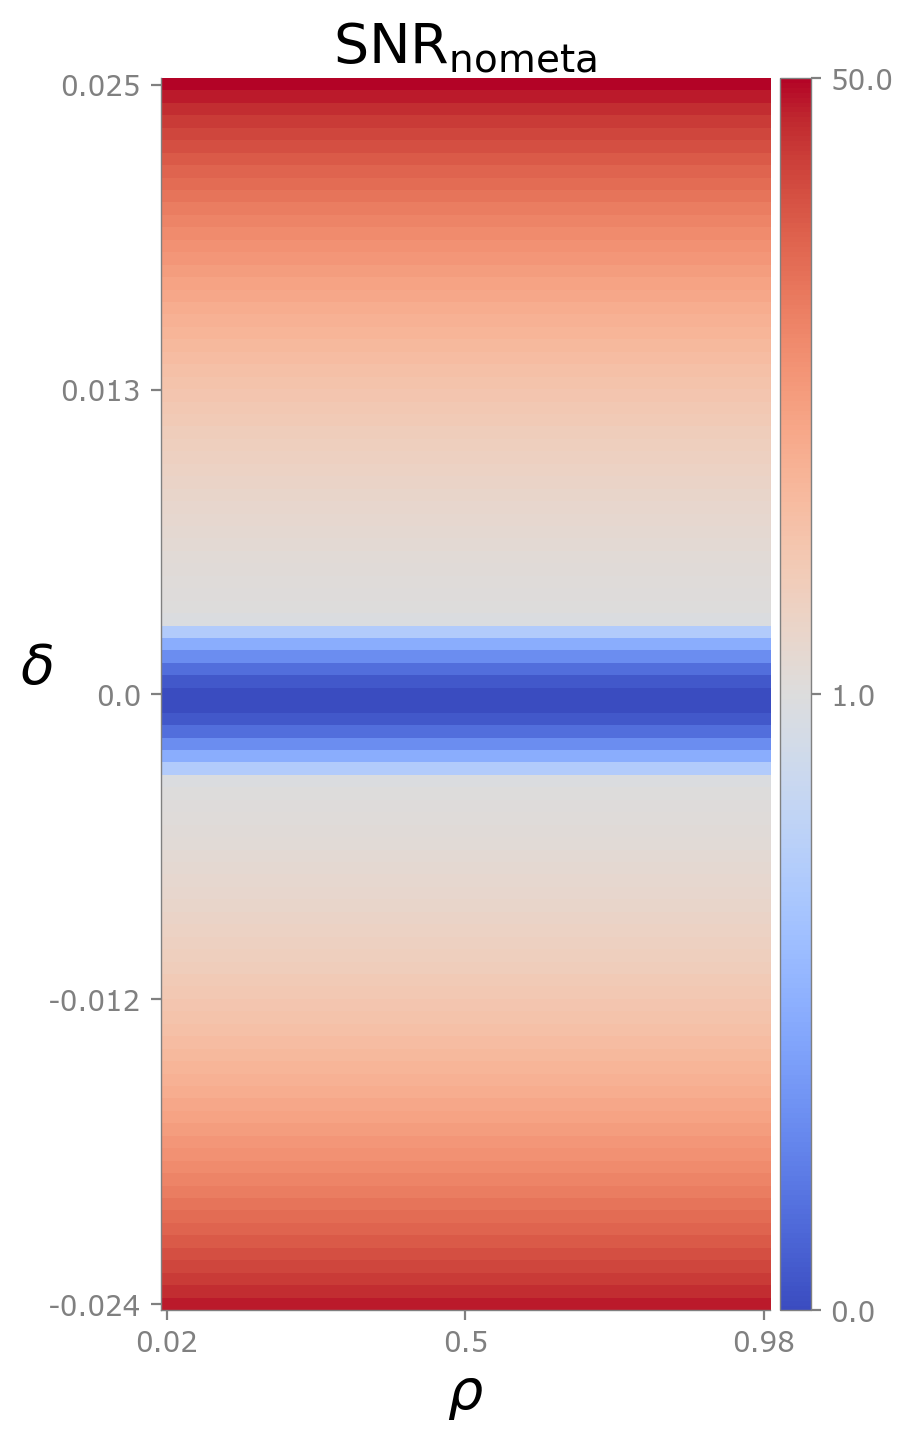

In [4]:
print(f"Z={Z}, d={d}, min_delta={min_delta}, max_delta={max_delta}")
print("min SNR_nm:", np.min(SNR_nm))
print("max SNR_nm:", np.max(SNR_nm))
print(f"min SNR={min_snr}")
print(f"max SNR={max_snr}")
x = np.repeat(rho, np.size(delta))
y = np.tile(delta, np.size(rho))
save_path = None
# save_path=None
fig = plt.figure(figsize=(8, 8))
widths = [8]
heights = [8]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
_ = color_imshow_2d(x, y, SNR_nm, z_center=1, title=r'$\rm SNR_{nometa}$', xlabel=r'$\rho$', ylabel=r'$\delta$', min_z=None, max_z=None, save_path=save_path, ax=ax, fig=fig)

4851


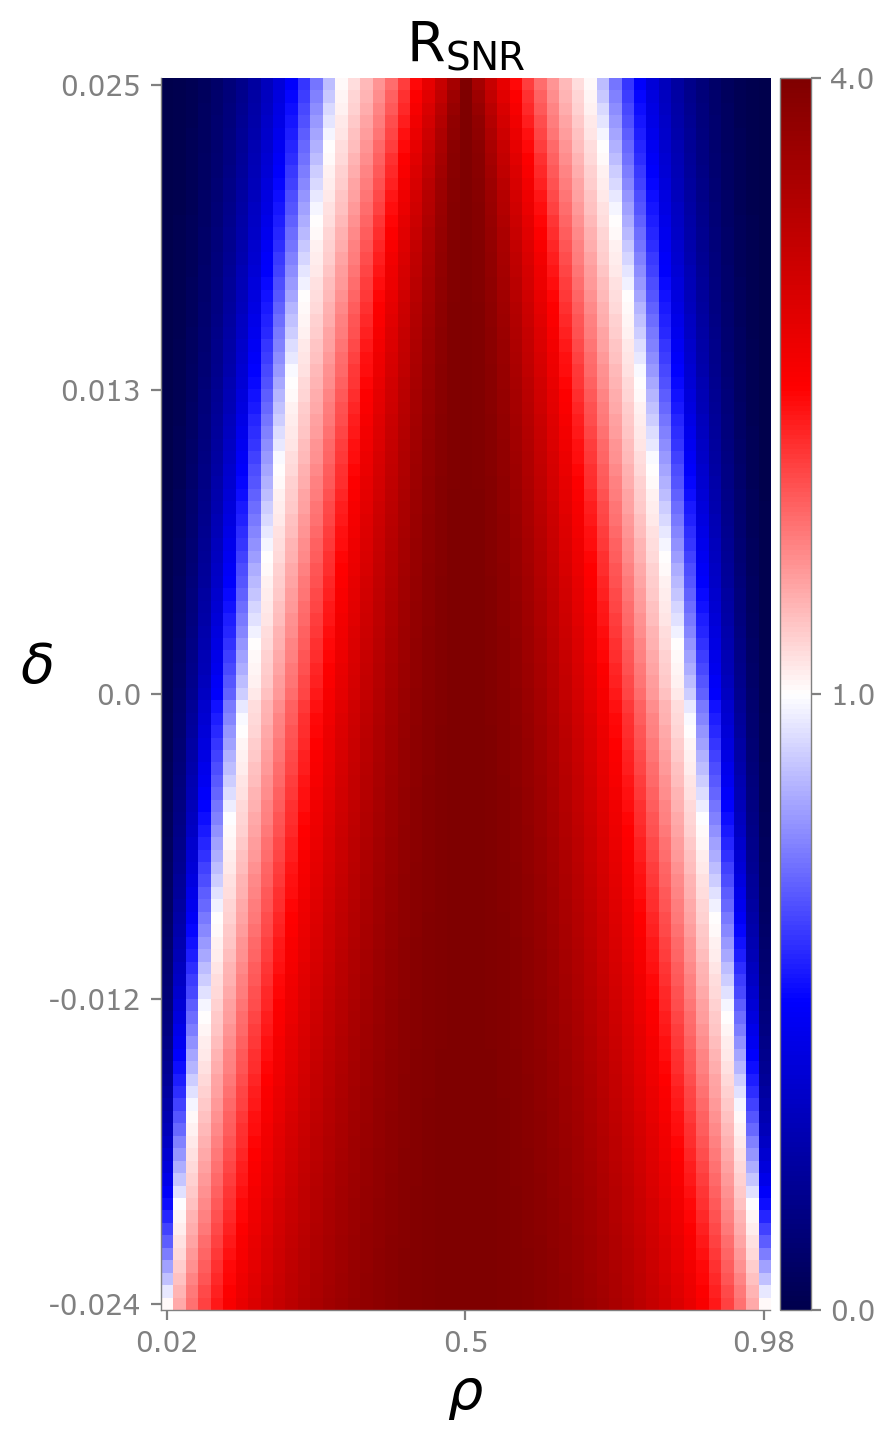

In [5]:
R_SNR=SNR_m/SNR_nm
print(np.size(R_SNR)) 
save_path =None
# save_path=None
fig = plt.figure(figsize=(8, 8))
widths = [8]
heights = [8]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
_ = color_imshow_2d(x, y, R_SNR, z_center=1, title=r'$\rm R_{SNR}$', xlabel=r'$\rho$', ylabel=r'$\delta$', cmap=cm.seismic, save_path=save_path, ax=ax, fig=fig)

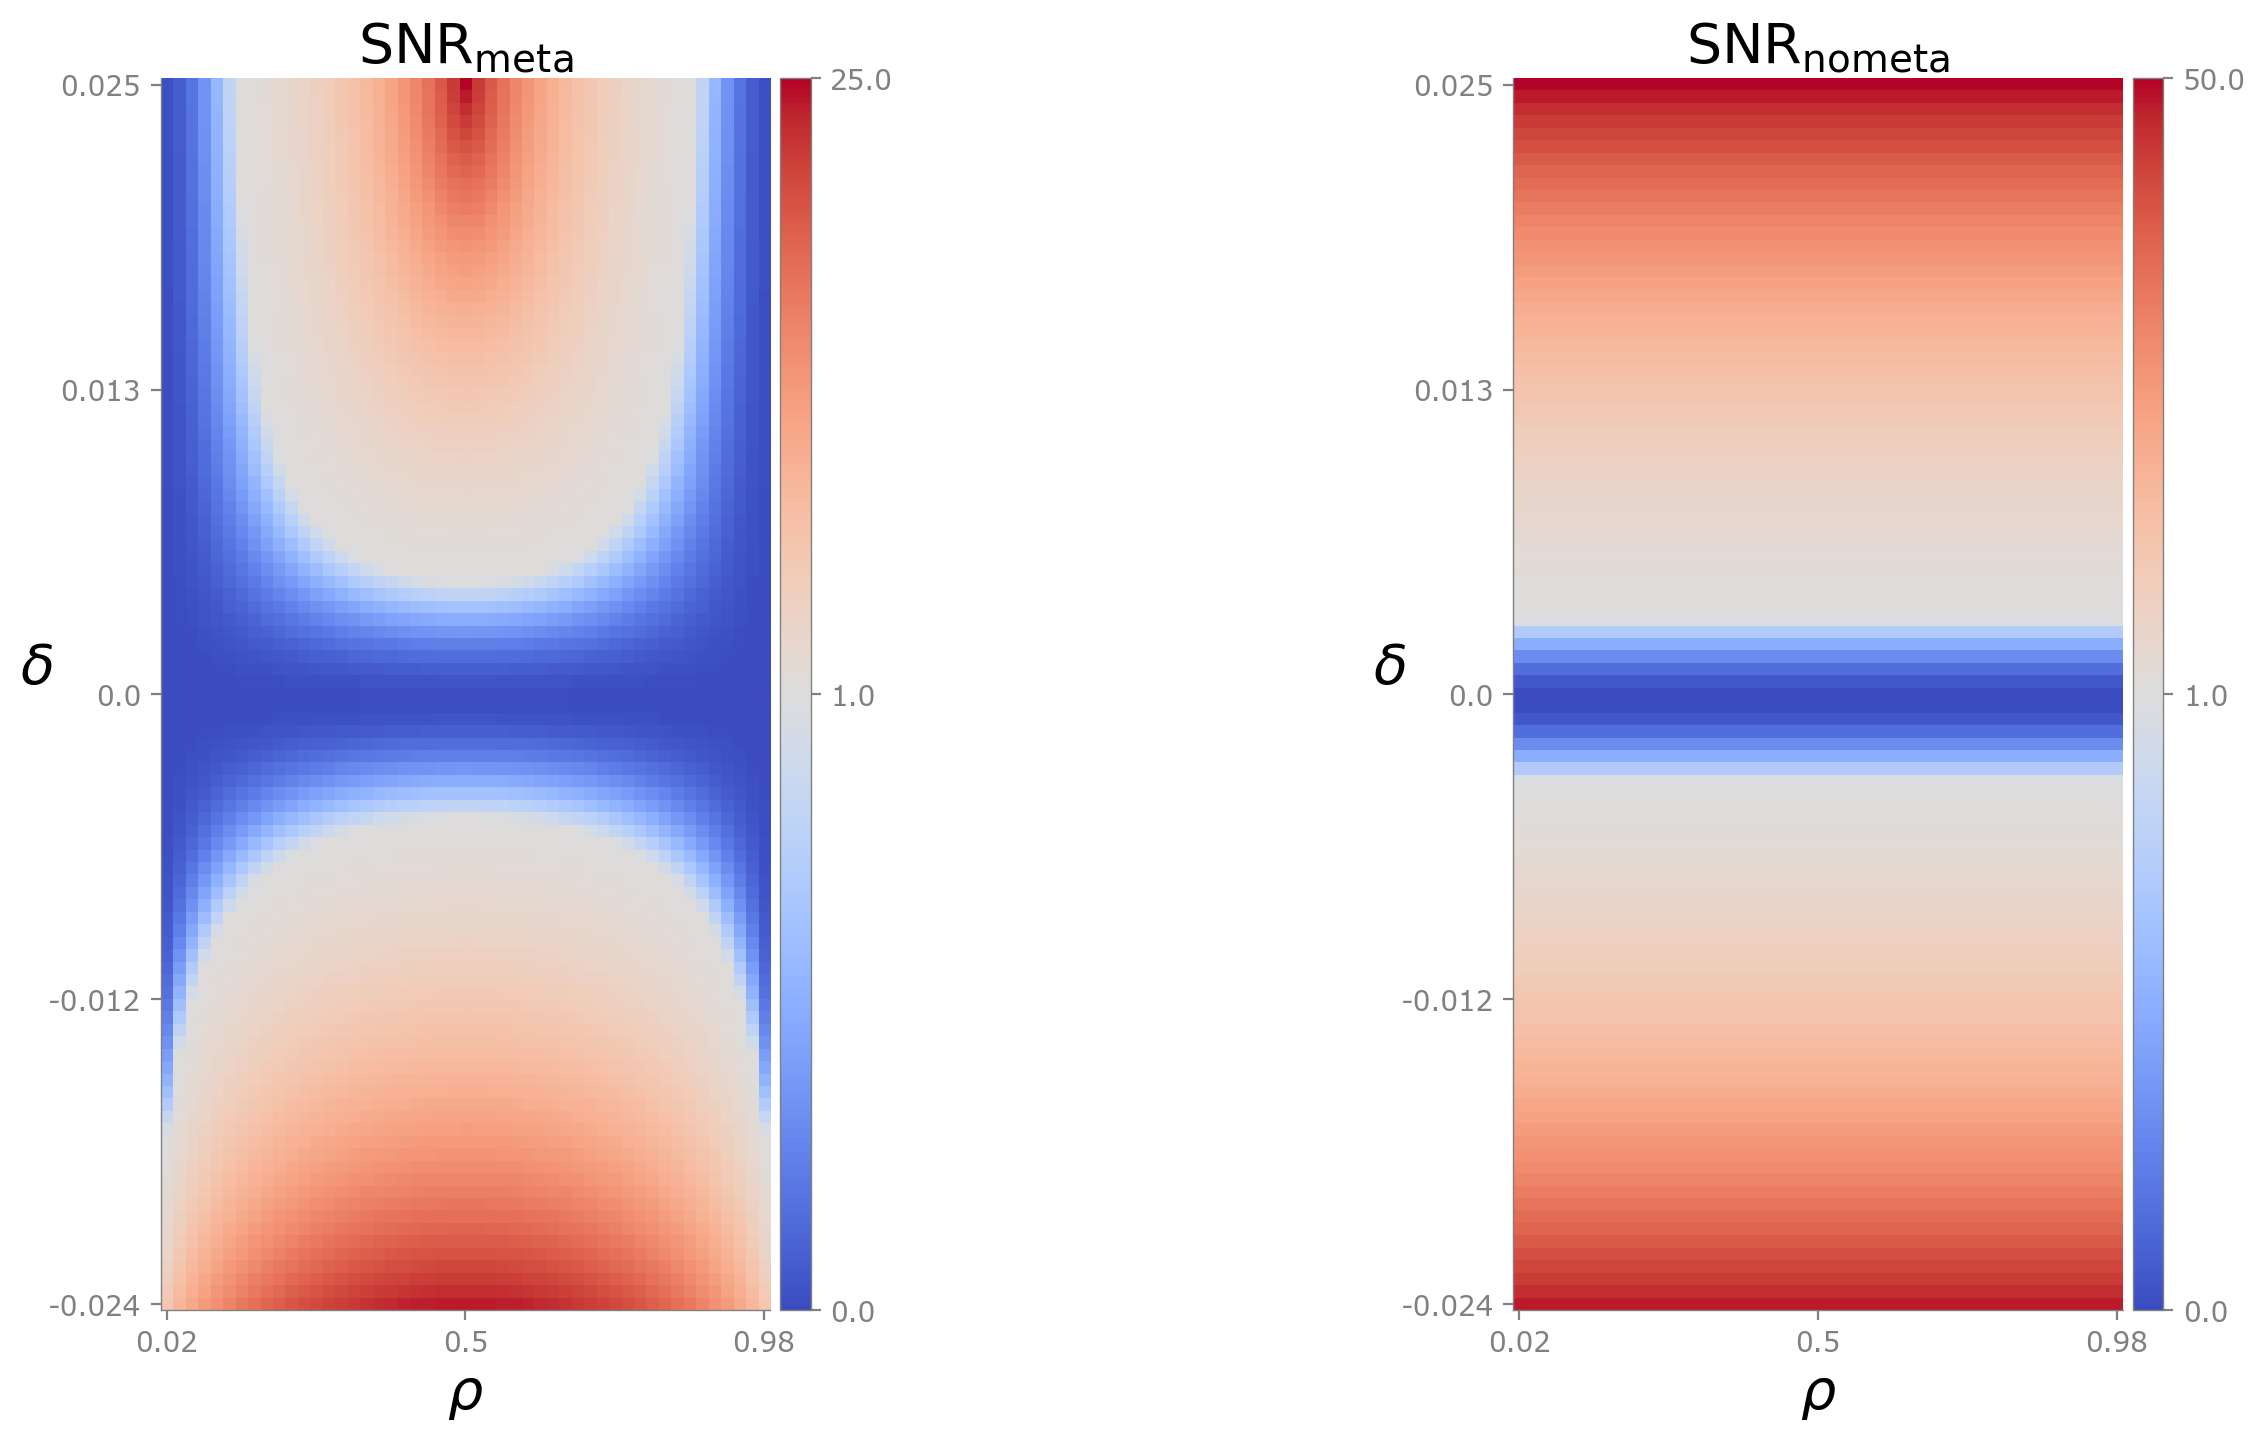

In [23]:
n = 4000
X = 2
Z = 1
d = 50  # 100~500
rho = np.setdiff1d(np.around(np.linspace(0, 1, 51), 2), np.array([0, 1]))
delta = np.setdiff1d(np.around(np.linspace(min_delta, max_delta, int((max_delta-min_delta)/0.0005)+1), 5), np.array([0, min_delta]))
SNR_m = np.zeros(np.size(delta)*np.size(rho))
SNR_nm = np.zeros(np.size(delta)*np.size(rho))
withTheory = False
i = 0
for _rho in rho:
    for _delta in delta:
        pin = d / n + _delta * (1 - 1 / (X * Z))
        pout = d / n - _delta / (X * Z)
        pin = 0 if pin < 1e-10 else pin
        pout = 0 if pout < 1e-10 else pout
#         print(f'rho={_rho}, delta={_delta}, pin={pin}, pout={pout}')
        msbm = SymMetaSBM(n, X, Z, _rho, pin, pout, quickwithoutmeta=True)
        SNR_m[i] = msbm.get_snr(withMeta=True, withTheory=withTheory)
        SNR_nm[i] = msbm.get_snr(withMeta=False, withTheory=withTheory)
        i += 1
x = np.repeat(rho, np.size(delta))
y = np.tile(delta, np.size(rho))
save_path = None
fig = plt.figure(figsize=(16, 8))
widths = [8, 8]
heights = [8]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
_ = color_imshow_2d(x, y, SNR_m, z_center=1, title=r'$\rm SNR_{meta}$', xlabel=r'$\rho$', ylabel=r'$\delta$', min_z=None, max_z=None, save_path=save_path, ax=ax, fig=fig)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
_ = color_imshow_2d(x, y, SNR_nm, z_center=1, title=r'$\rm SNR_{nometa}$', xlabel=r'$\rho$', ylabel=r'$\delta$', min_z=None, max_z=None, save_path=save_path, ax=ax, fig=fig)